
# Player Churn Risk Prediction — Game Analytics

## Fase 1: Análisis, preparación y modelado inicial

### Descripción del proyecto

Este proyecto aborda el problema de abandono de jugadores en un videojuego en línea mediante técnicas de aprendizaje automático. A partir de información histórica de comportamiento y telemetría, se busca identificar patrones asociados con jugadores que dejan de participar en el juego.

El conjunto de datos contiene información sobre sesiones, actividad dentro de stages, patrones temporales de interacción, permanencia y otras características relacionadas con el comportamiento de cada jugador.

El proyecto se desarrolla como un problema de clasificación binaria supervisada, donde el objetivo consiste en estimar si un jugador pertenece a la clase de churn o permanencia.

### Objetivo

Construir una primera solución reproducible de clasificación que permita identificar jugadores con riesgo de abandono, comparar modelos iniciales y analizar los errores relevantes para un escenario de retención.

Esta primera fase establece la línea base del sistema y servirá como punto de partida para posteriores etapas de optimización, validación, interpretabilidad y despliegue.



## 1. Definición del problema

### Contexto organizacional

Para un videojuego en línea, la pérdida de jugadores puede reducir la actividad de la comunidad y afectar métricas relacionadas con retención y participación. Identificar anticipadamente señales asociadas con el abandono permitiría a un equipo de analítica o retención priorizar jugadores que podrían requerir acciones de reactivación, incentivos o análisis adicional.

### Formulación como problema de aprendizaje automático

La necesidad de retención se transforma en una tarea de **clasificación binaria supervisada**.

- **Unidad de análisis:** jugador.
- **Variable objetivo:** `player_churn`.
- **Clase negativa (0):** jugador que permanece.
- **Clase positiva (1):** jugador que presenta churn.
- **Predictores:** características históricas de actividad, sesiones, stages, permanencia y patrones temporales del jugador.

La clase positiva se establece como churn debido a que representa el evento que interesa detectar para apoyar acciones de retención.

### Pregunta guía

**¿En qué medida los patrones históricos de actividad y permanencia permiten identificar jugadores con mayor probabilidad de churn?**

### Usuario y decisión apoyada

El modelo está planteado como una herramienta de apoyo para equipos de analítica y retención. Su resultado puede utilizarse para priorizar jugadores según su riesgo estimado de abandono y orientar posteriormente estrategias de retención.

La predicción no representa certeza de abandono y no debe utilizarse como única fuente para tomar decisiones sobre un jugador.

### Riesgo de uso incorrecto

Un uso inadecuado sería interpretar la clasificación como una certeza o aplicar automáticamente acciones costosas a todos los jugadores clasificados en riesgo. Los falsos positivos pueden provocar intervenciones innecesarias, mientras que los falsos negativos representan jugadores que podrían abandonar sin ser detectados.

Por esta razón, además del desempeño global, será necesario analizar explícitamente ambos tipos de error.

### Criterio inicial de éxito

El modelo deberá superar claramente una línea base basada en la clase mayoritaria y demostrar capacidad para detectar la clase positiva.

Debido al contexto de retención, se dará especial importancia al **recall de churn**, ya que un falso negativo representa un jugador que abandona sin ser identificado previamente. Sin embargo, la selección no se realizará utilizando una sola métrica: se analizarán conjuntamente accuracy, precision, recall, F1 y ROC-AUC, además de las matrices de confusión.

Como referencia inicial, se buscará alcanzar un recall de churn de al menos 0.70 en validación, acompañado de mejoras sustanciales frente al modelo baseline en F1 y ROC-AUC, pero Al tratarse de una primera aproximación exploratoria, no se establece retrospectivamente un valor mínimo de desempeño después de observar los resultados. El criterio de éxito se basa en superar de forma sustancial el baseline y conseguir un equilibrio entre recall, precision, F1 y ROC-AUC coherente con el costo de los errores en el contexto de retención.

## 2. Fuente y comprensión del conjunto de datos

### Fuente

Para el desarrollo del proyecto se utiliza el conjunto de datos **Player Churn**, proporcionado como conjunto de datos de ejemplo dentro de una solución de AWS orientada a la predicción del comportamiento de jugadores mediante inteligencia artificial.

El dataset contiene información de telemetría agregada a nivel jugador. Entre sus variables se encuentran características relacionadas con sesiones, actividad dentro de stages, patrones temporales de uso, permanencia y cohortes.

El conjunto utilizado contiene **2,096 jugadores y 187 variables**.

La variable objetivo es `player_churn`, que indica si el jugador fue clasificado como churn (`True`) o no churn (`False`).

### Naturaleza de los datos

El conjunto de datos utilizado es de naturaleza sintética y fue generado para representar patrones de comportamiento de jugadores. Esta característica permite desarrollar y evaluar el flujo completo de aprendizaje automático, aunque debe considerarse como una limitación al interpretar los resultados: el desempeño obtenido no implica necesariamente el mismo comportamiento sobre jugadores de un videojuego real.

### Estructura general de las variables

Las 187 variables pueden organizarse principalmente en las siguientes familias:

- **Identificación:** `player_id`.
- **Cohorte:** `cohort_id` y `cohort_day_of_week`.
- **Características del jugador:** `player_type` y `player_lifetime`.
- **Actividad global:** variables como `session_count`.
- **Actividad de sesiones:** conteos de inicio y fin de sesiones en diferentes ventanas temporales.
- **Actividad en stages:** conteos de inicio y fin de stages en diferentes ventanas temporales.
- **Patrones temporales:** medias y desviaciones estándar de la hora del día en que ocurren sesiones y stages.
- **Variable objetivo:** `player_churn`.

Las variables temporales utilizan diferentes ventanas de observación, incluyendo días, semanas y meses anteriores. Por ejemplo, nombres como `last_day(-1)` representan información correspondiente a una ventana temporal previa.

Debido a esta estructura temporal, posteriormente se realizará un análisis específico de posibles fugas de información antes de seleccionar los predictores utilizados por los modelos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
# Subir archivo
uploaded = files.upload()
# Detectar automáticamente el nombre del archivo
archivo = next(iter(uploaded))
# Cargar dataset
df = pd.read_csv(archivo)
print("Archivo cargado:", archivo)
print("Dimensiones:", df.shape)
print("\nPrimeras 5 filas:")
display(df.head())
print("\nÚltimas 5 filas:")
display(df.tail())

Saving player-churn.csv to player-churn (3).csv
Archivo cargado: player-churn (3).csv
Dimensiones: (2096, 187)

Primeras 5 filas:


,player_id,cohort_id,cohort_day_of_week,player_type,player_lifetime,session_count,player_churn,begin_session_count_last_day(-1),end_session_count_last_day(-1),begin_stage_count_last_day(-1),...,begin_stage_time_of_day_std_last_week(-3),end_stage_time_of_day_std_last_week(-3),begin_session_time_of_day_std_last_month(-1),end_session_time_of_day_std_last_month(-1),begin_stage_time_of_day_std_last_month(-1),end_stage_time_of_day_std_last_month(-1),begin_session_time_of_day_std_last_month(-2),end_session_time_of_day_std_last_month(-2),begin_stage_time_of_day_std_last_month(-2),end_stage_time_of_day_std_last_month(-2)
0,2aea54bf5981406aa8cce01ad9b29bde,2023_01_01,6,casual,1.012327e+06,9,False,3,3,62,...,0,0,352344.072018,353109.477306,319182.655501,319182.886205,0,0,0,0
1,049eeae96b0a43869e5f644f629d0742,2023_01_01,6,hardcore,1.002068e+06,11,False,1,2,75,...,0,0,321005.208979,321245.297479,303668.556197,303668.374577,0,0,0,0
2,6e03427f185a4462a689c611f61b3d2d,2023_01_01,6,hardcore,9.631331e+05,11,False,1,1,23,...,0,0,291329.743010,291484.586872,269880.175795,269880.312841,0,0,0,0
3,87e5b041ae2c4f5b85ce17a5962f4c84,2023_01_02,0,hardcore,9.036585e+05,15,False,1,1,24,...,0,0,304353.409418,304985.700571,288815.899256,288815.569410,0,0,0,0
4,2d2b3aadbfe04fd2b3cc239c815a0e70,2023_01_02,0,hardcore,8.654448e+05,10,False,2,2,42,...,0,0,302091.013943,303183.392338,276028.848454,276028.331858,0,0,0,0



Últimas 5 filas:


,player_id,cohort_id,cohort_day_of_week,player_type,player_lifetime,session_count,player_churn,begin_session_count_last_day(-1),end_session_count_last_day(-1),begin_stage_count_last_day(-1),...,begin_stage_time_of_day_std_last_week(-3),end_stage_time_of_day_std_last_week(-3),begin_session_time_of_day_std_last_month(-1),end_session_time_of_day_std_last_month(-1),begin_stage_time_of_day_std_last_month(-1),end_stage_time_of_day_std_last_month(-1),begin_session_time_of_day_std_last_month(-2),end_session_time_of_day_std_last_month(-2),begin_stage_time_of_day_std_last_month(-2),end_stage_time_of_day_std_last_month(-2)
2091,92465184bc224304b1b59d9e2c6aea48,2023_01_12,3,casual,7168.441917,1,False,1,1,19,...,0,0,NaN,NaN,2090.901035,2090.228077,0,0,0,0
2092,dcae943ace394c17ac8301ea7d2621c4,2023_01_12,3,casual,7237.135615,1,False,1,1,23,...,0,0,NaN,NaN,2120.957815,2123.101179,0,0,0,0
2093,4f0737a48b1a49abb157f174fdd62ab9,2023_01_13,4,casual,3017.547043,1,False,1,1,16,...,0,0,NaN,NaN,861.377315,859.741950,0,0,0,0
2094,40e28c09bcae4d999facb822aff1c0a5,2023_01_13,4,casual,3189.869447,1,False,1,1,8,...,0,0,NaN,NaN,895.436708,899.204052,0,0,0,0
2095,b393702a72154a0dadc9b8089374358c,2023_01_14,5,casual,4006.429002,1,False,1,1,10,...,0,0,NaN,NaN,1143.960282,1140.761368,0,0,0,0


### 2.1 Estructura general

Una vez cargado el archivo, se realiza una inspección inicial para verificar sus dimensiones, columnas y estructura.

Cada fila representa a un jugador y cada columna corresponde a una característica de identificación, cohorte, comportamiento, actividad temporal o a la variable objetivo.

In [2]:
#Estructura del dataset
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])
print("\nColumnas:")
for i, columna in enumerate(df.columns, 1):
    print(f"{i}. {columna}")
print("\nTipos de datos:")
print(df.dtypes.value_counts())
print("\nInformación general:")
df.info()

Número de filas: 2096
Número de columnas: 187

Columnas:
1. player_id
2. cohort_id
3. cohort_day_of_week
4. player_type
5. player_lifetime
6. session_count
7. player_churn
8. begin_session_count_last_day(-1)
9. end_session_count_last_day(-1)
10. begin_stage_count_last_day(-1)
11. end_stage_count_last_day(-1)
12. begin_session_count_last_day(-2)
13. end_session_count_last_day(-2)
14. begin_stage_count_last_day(-2)
15. end_stage_count_last_day(-2)
16. begin_session_count_last_day(-3)
17. end_session_count_last_day(-3)
18. begin_stage_count_last_day(-3)
19. end_stage_count_last_day(-3)
20. begin_session_count_last_day(-4)
21. end_session_count_last_day(-4)
22. begin_stage_count_last_day(-4)
23. end_stage_count_last_day(-4)
24. begin_session_count_last_day(-5)
25. end_session_count_last_day(-5)
26. begin_stage_count_last_day(-5)
27. end_stage_count_last_day(-5)
28. begin_session_count_last_day(-6)
29. end_session_count_last_day(-6)
30. begin_stage_count_last_day(-6)
31. end_stage_count_las

### 2.2 Diccionario de variables

Debido a que el conjunto contiene 187 variables, se construye un diccionario reproducible directamente a partir del dataset.

Para cada característica se registra su nombre, tipo de dato, cantidad de valores únicos, valores faltantes y una descripción basada en la función representada por su nombre.

Esto facilita la comprensión del conjunto y permite identificar posteriormente variables que requieren tratamientos específicos.

In [3]:
#Diccionario de variables
def tipo_analitico(col):
    if col == "player_churn":
        return "Binaria"
    elif col == "player_id":
        return "Identificador"
    elif col in ["cohort_id", "player_type", "cohort_day_of_week"]:
        return "Categórica"
    elif pd.api.types.is_numeric_dtype(df[col]):
        return "Numérica"
    else:
        return "Otra"
def rol_variable(col):
    if col == "player_churn":
        return "Objetivo"
    elif col == "player_id":
        return "Identificador"
    else:
        return "Predictora"
def tratamiento_previsto(col):
    if col == "player_churn":
        return "Codificar como 0 = no churn y 1 = churn"
    elif col == "player_id":
        return "Excluir del modelado"
    elif col == "player_type":
        return "Excluir por riesgo de leakage"
    elif col == "cohort_id":
        return "Excluir por riesgo temporal"
    elif col in columnas_constantes if "columnas_constantes" in globals() else False:
        return "Excluir por varianza cero"
    elif col == "cohort_day_of_week":
        return "Imputación por moda + One-Hot Encoding"
    elif pd.api.types.is_numeric_dtype(df[col]):
        return "Imputación por mediana + estandarización"
    else:
        return "Revisión según tipo"
def unidad_escala(col):
    if "count" in col:
        return "Conteo"
    elif "time_of_day" in col:
        return "Tiempo del día"
    elif col == "player_lifetime":
        return "Tiempo de permanencia"
    elif col == "cohort_day_of_week":
        return "Categorías 0-6"
    elif col == "player_churn":
        return "Binaria"
    elif col == "player_id":
        return "Identificador"
    else:
        return "Según definición de la variable"
diccionario = pd.DataFrame({
    "Variable": df.columns,
    "Descripcion": [
        "Variable de telemetría o característica del jugador asociada al comportamiento dentro del juego."
        for _ in df.columns
    ],
    "Tipo_original": [str(df[col].dtype) for col in df.columns],
    "Tipo_analitico": [tipo_analitico(col) for col in df.columns],
    "Rol": [rol_variable(col) for col in df.columns],
    "Unidad_escala": [unidad_escala(col) for col in df.columns],
    "Valores_faltantes": [df[col].isna().sum() for col in df.columns],
    "Porcentaje_faltantes": [df[col].isna().mean() * 100 for col in df.columns],
    "Tratamiento_previsto": [tratamiento_previsto(col) for col in df.columns]
})
diccionario

,Variable,Descripcion,Tipo_original,Tipo_analitico,Rol,Unidad_escala,Valores_faltantes,Porcentaje_faltantes,Tratamiento_previsto
0,player_id,Variable de telemetría o característica del ju...,object,Identificador,Identificador,Identificador,0,0.0,Excluir del modelado
1,cohort_id,Variable de telemetría o característica del ju...,object,Categórica,Predictora,Según definición de la variable,0,0.0,Excluir por riesgo temporal
2,cohort_day_of_week,Variable de telemetría o característica del ju...,int64,Categórica,Predictora,Categorías 0-6,0,0.0,Imputación por moda + One-Hot Encoding
3,player_type,Variable de telemetría o característica del ju...,object,Categórica,Predictora,Según definición de la variable,0,0.0,Excluir por riesgo de leakage
4,player_lifetime,Variable de telemetría o característica del ju...,float64,Numérica,Predictora,Tiempo de permanencia,0,0.0,Imputación por mediana + estandarización
...,...,...,...,...,...,...,...,...,...
182,end_stage_time_of_day_std_last_month(-1),Variable de telemetría o característica del ju...,float64,Numérica,Predictora,Tiempo del día,0,0.0,Imputación por mediana + estandarización
183,begin_session_time_of_day_std_last_month(-2),Variable de telemetría o característica del ju...,int64,Numérica,Predictora,Tiempo del día,0,0.0,Imputación por mediana + estandarización
184,end_session_time_of_day_std_last_month(-2),Variable de telemetría o característica del ju...,int64,Numérica,Predictora,Tiempo del día,0,0.0,Imputación por mediana + estandarización
185,begin_stage_time_of_day_std_last_month(-2),Variable de telemetría o característica del ju...,int64,Numérica,Predictora,Tiempo del día,0,0.0,Imputación por mediana + estandarización


### 2.3 Organización de las características

Las variables se revisan de forma estructurada para identificar sus tipos y agruparlas según la información que representan.

De manera general, el dataset contiene:

- variables de identificación;
- información de cohorte;
- características generales del jugador;
- conteos de sesiones;
- conteos de actividad dentro de stages;
- medidas temporales de actividad;
- variable objetivo.

Esta organización permitirá seleccionar posteriormente el tratamiento adecuado para cada tipo de predictor.

In [4]:
#Ahora necesitamos conocer las 187 variables sin volvernos locos
#En vez de imprimirlas todas y revisarlas manualmente, vamos a clasificarlas automáticamente por familias.

In [5]:
# Resumen de tipos de variables
resumen_tipos = pd.DataFrame({
    "tipo": df.dtypes,
    "unicos": df.nunique(),
    "faltantes": df.isnull().sum(),
    "porcentaje_faltantes": (df.isnull().mean() * 100).round(2)
})
print("Variables numéricas:",
      df.select_dtypes(include=np.number).shape[1])
print("Variables categóricas:",
      df.select_dtypes(include=["object", "category"]).shape[1])
print("Variables booleanas:",
      df.select_dtypes(include="bool").shape[1])
display(resumen_tipos)

Variables numéricas: 183
Variables categóricas: 3
Variables booleanas: 1


,tipo,unicos,faltantes,porcentaje_faltantes
player_id,object,2096,0,0.0
cohort_id,object,14,0,0.0
cohort_day_of_week,int64,7,0,0.0
player_type,object,3,0,0.0
player_lifetime,float64,2096,0,0.0
...,...,...,...,...
end_stage_time_of_day_std_last_month(-1),float64,2096,0,0.0
begin_session_time_of_day_std_last_month(-2),int64,1,0,0.0
end_session_time_of_day_std_last_month(-2),int64,1,0,0.0
begin_stage_time_of_day_std_last_month(-2),int64,1,0,0.0


In [6]:
#Agrupar las columnas por familia
familias = {
    "Identificación": [],
    "Sesiones": [],
    "Stages": [],
    "Horarios": [],
    "Cohorte": [],
    "Jugador": [],
    "Otras": []
}

for col in df.columns:
    nombre = col.lower()

    if "player_id" in nombre:
        familias["Identificación"].append(col)
    elif "session" in nombre:
        familias["Sesiones"].append(col)
    elif "stage" in nombre:
        familias["Stages"].append(col)
    elif "time_of_day" in nombre:
        familias["Horarios"].append(col)
    elif "cohort" in nombre:
        familias["Cohorte"].append(col)
    elif "player" in nombre:
        familias["Jugador"].append(col)
    else:
        familias["Otras"].append(col)

for familia, columnas in familias.items():
    print(f"\n{familia}: {len(columnas)} variables")
    print(columnas[:10])


Identificación: 1 variables
['player_id']

Sesiones: 91 variables
['session_count', 'begin_session_count_last_day(-1)', 'end_session_count_last_day(-1)', 'begin_session_count_last_day(-2)', 'end_session_count_last_day(-2)', 'begin_session_count_last_day(-3)', 'end_session_count_last_day(-3)', 'begin_session_count_last_day(-4)', 'end_session_count_last_day(-4)', 'begin_session_count_last_day(-5)']

Stages: 90 variables
['begin_stage_count_last_day(-1)', 'end_stage_count_last_day(-1)', 'begin_stage_count_last_day(-2)', 'end_stage_count_last_day(-2)', 'begin_stage_count_last_day(-3)', 'end_stage_count_last_day(-3)', 'begin_stage_count_last_day(-4)', 'end_stage_count_last_day(-4)', 'begin_stage_count_last_day(-5)', 'end_stage_count_last_day(-5)']

Horarios: 0 variables
[]

Cohorte: 2 variables
['cohort_id', 'cohort_day_of_week']

Jugador: 3 variables
['player_type', 'player_lifetime', 'player_churn']

Otras: 0 variables
[]


In [7]:
#Variables categóricas y de baja cardinalidad
columnas_baja_cardinalidad = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 15
]

print("Variables con 15 categorías/valores únicos o menos:",
      len(columnas_baja_cardinalidad))

for col in columnas_baja_cardinalidad:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))

Variables con 15 categorías/valores únicos o menos: 59

--- cohort_id ---
cohort_id
2023_01_08    597
2023_01_10    390
2023_01_06    284
2023_01_05    258
2023_01_04    228
2023_01_03    187
2023_01_09     65
2023_01_11     45
2023_01_07     30
2023_01_12      4
2023_01_01      3
2023_01_02      2
2023_01_13      2
2023_01_14      1
Name: count, dtype: int64

--- cohort_day_of_week ---
cohort_day_of_week
6    600
1    577
4    286
2    273
3    262
0     67
5     31
Name: count, dtype: int64

--- player_type ---
player_type
churner     1897
casual       114
hardcore      85
Name: count, dtype: int64

--- session_count ---
session_count
3     640
2     617
4     318
1     273
5     143
6      44
7      19
9      12
8       8
10      8
11      6
14      3
15      2
12      2
13      1
Name: count, dtype: int64

--- player_churn ---
player_churn
False    1174
True      922
Name: count, dtype: int64

--- begin_session_count_last_day(-1) ---
begin_session_count_last_day(-1)
1    1782
2    

In [8]:
#Auditoría adicional de calidad
columnas_texto = df.select_dtypes(include="object").columns.tolist()
# Categorías con posibles espacios o inconsistencias
revision_categorias = []
for col in columnas_texto:
    valores = df[col].dropna().astype(str)
    espacios = (valores != valores.str.strip()).sum()
    categorias_originales = valores.nunique()
    categorias_normalizadas = valores.str.strip().str.lower().nunique()
    revision_categorias.append({
        "Variable": col,
        "Categorias_originales": categorias_originales,
        "Categorias_normalizadas": categorias_normalizadas,
        "Valores_con_espacios": espacios
    })
revision_categorias = pd.DataFrame(revision_categorias)
print("Revisión de categorías:")
display(revision_categorias)
# Buscar columnas tipo texto que pudieran ser realmente numéricas
numericas_como_texto = []
for col in columnas_texto:
    conversion = pd.to_numeric(df[col], errors="coerce")
    valores_no_nulos = df[col].notna().sum()
    convertibles = conversion.notna().sum()
    if valores_no_nulos > 0 and convertibles == valores_no_nulos:
        numericas_como_texto.append(col)
print("\nColumnas numéricas almacenadas como texto:")
print(numericas_como_texto)

Revisión de categorías:


,Variable,Categorias_originales,Categorias_normalizadas,Valores_con_espacios
0,player_id,2096,2096,0
1,cohort_id,14,14,0
2,player_type,3,3,0



Columnas numéricas almacenadas como texto:
[]


### 2.4 Revisión de consistencia de tipos y categorías

Se realizó una revisión específica de las variables categóricas para detectar espacios adicionales, diferencias de escritura y posibles categorías inconsistentes.

También se verificó si alguna columna almacenada como texto podía representar realmente una variable numérica.

Esta comprobación complementa el diagnóstico general de calidad y permite evitar errores derivados de codificaciones inconsistentes antes del modelado.

## 3. Exploración inicial y calidad de los datos

Antes de construir los modelos se revisa la calidad del conjunto de datos para identificar problemas que puedan afectar el análisis o producir resultados poco confiables.

La revisión considera valores faltantes, duplicados, cardinalidad, distribución de la variable objetivo, variables constantes o casi constantes y posibles valores extremos.

In [9]:
#Calidad inicial
print("Valores faltantes totales:", df.isnull().sum().sum())
print("Filas duplicadas:", df.duplicated().sum())
faltantes = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)
faltantes = faltantes[faltantes > 0]
print("\nColumnas con valores faltantes:")
display(faltantes.to_frame("Valores faltantes"))

Valores faltantes totales: 11231
Filas duplicadas: 0

Columnas con valores faltantes:


,Valores faltantes
begin_session_time_of_day_std_last_day(-1),1782
end_session_time_of_day_std_last_day(-1),1653
begin_session_time_of_day_std_last_day(-2),685
end_session_time_of_day_std_last_day(-2),679
begin_session_time_of_day_std_last_day(-3),640
end_session_time_of_day_std_last_day(-3),587
end_session_time_of_day_std_last_day(-4),502
begin_session_time_of_day_std_last_day(-5),496
begin_session_time_of_day_std_last_day(-4),481
end_session_time_of_day_std_last_day(-5),430


In [10]:
#Siguiente bloque: entender los faltantes
#Necesitamos distinguir entre NaN porque falta información y NaN porque matemáticamente no se puede calcular una desviación estándar.

In [11]:
# Analizar patrón de valores faltantes

missing_info = pd.DataFrame({
    "faltantes": df.isnull().sum(),
    "porcentaje": (df.isnull().mean() * 100).round(2),
    "tipo": df.dtypes
})

missing_info = missing_info[missing_info["faltantes"] > 0]
missing_info = missing_info.sort_values("porcentaje", ascending=False)

print("Columnas con valores faltantes:", len(missing_info))
print("Total de valores faltantes:", df.isnull().sum().sum())

display(missing_info)

Columnas con valores faltantes: 42
Total de valores faltantes: 11231


,faltantes,porcentaje,tipo
begin_session_time_of_day_std_last_day(-1),1782,85.02,float64
end_session_time_of_day_std_last_day(-1),1653,78.86,float64
begin_session_time_of_day_std_last_day(-2),685,32.68,float64
end_session_time_of_day_std_last_day(-2),679,32.40,float64
begin_session_time_of_day_std_last_day(-3),640,30.53,float64
end_session_time_of_day_std_last_day(-3),587,28.01,float64
end_session_time_of_day_std_last_day(-4),502,23.95,float64
begin_session_time_of_day_std_last_day(-5),496,23.66,float64
begin_session_time_of_day_std_last_day(-4),481,22.95,float64
end_session_time_of_day_std_last_day(-5),430,20.52,float64


In [12]:
# Clasificar las columnas que contienen valores faltantes
missing_std = [
    col for col in missing_info.index
    if "_std_" in col
]
missing_no_std = [
    col for col in missing_info.index
    if "_std_" not in col
]
print("Columnas con faltantes correspondientes a STD:",
      len(missing_std))
print("Columnas con faltantes que NO corresponden a STD:",
      len(missing_no_std))
print("\nColumnas NO-STD con faltantes:")
print(missing_no_std)

Columnas con faltantes correspondientes a STD: 42
Columnas con faltantes que NO corresponden a STD: 0

Columnas NO-STD con faltantes:
[]


### 3.1 Valores faltantes y duplicados

Se detectaron **11,231 valores faltantes distribuidos en 42 variables**, mientras que no se encontraron registros duplicados.

Las 42 columnas con valores ausentes corresponden exclusivamente a variables de desviación estándar (`std`) asociadas con patrones temporales de actividad.

La concentración de los valores faltantes en este tipo de características sugiere que no se trata de ausencia aleatoria generalizada. Una desviación estándar requiere múltiples observaciones dentro de una ventana temporal, por lo que algunos jugadores pueden no disponer de actividad suficiente para calcularla.

Por esta razón, no se eliminarán observaciones completas. Los valores faltantes serán tratados posteriormente mediante imputación dentro del pipeline de preprocesamiento.

### 3.2 Distribución de la variable objetivo

Se analiza la frecuencia de las clases para determinar si existe un problema relevante de desbalance y establecer una referencia inicial para la evaluación de los modelos.

In [13]:
#Nuestro target
print("Valores de player_churn:")
print(df["player_churn"].value_counts())
print("\nDistribución porcentual:")
print(
    df["player_churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Valores de player_churn:
player_churn
False    1174
True      922
Name: count, dtype: int64

Distribución porcentual:
player_churn
False    56.01
True     43.99
Name: proportion, dtype: float64


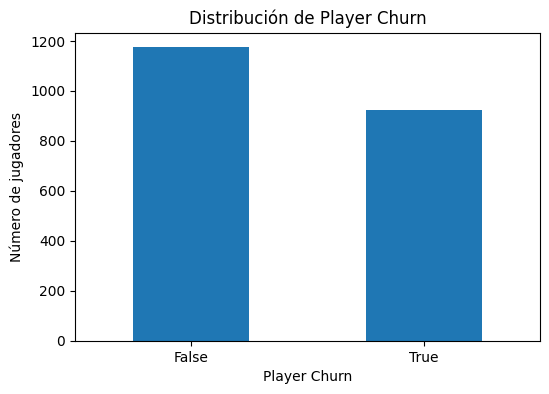

In [14]:
#Grafica del target
churn_counts = df["player_churn"].value_counts()
plt.figure(figsize=(6, 4))
churn_counts.plot(kind="bar")
plt.title("Distribución de Player Churn")
plt.xlabel("Player Churn")
plt.ylabel("Número de jugadores")
plt.xticks(rotation=0)
plt.show()

La variable objetivo contiene:

- **1,174 jugadores sin churn (56.01%)**.
- **922 jugadores con churn (43.99%)**.

Existe una diferencia entre ambas clases, pero no se observa un desbalance extremo. Por este motivo no se aplicarán técnicas de sobremuestreo o submuestreo durante esta primera fase.

Sin embargo, la distribución muestra por qué accuracy no debe utilizarse de forma aislada: un modelo que predijera siempre la clase mayoritaria podría superar 56% de accuracy sin identificar correctamente ningún caso de churn.

Por esta razón, posteriormente se evaluarán también precision, recall, F1 y ROC-AUC.

### 3.3 Variables constantes y de baja variabilidad

Se revisan las columnas con poca o ninguna variabilidad, ya que este tipo de características puede aportar escasa información al proceso de clasificación.

In [15]:
#Detectar variables constantes
columnas_constantes = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 1
]
print("Número de variables constantes:", len(columnas_constantes))
for col in columnas_constantes:
    print(col)

Número de variables constantes: 24
begin_session_count_last_week(-3)
end_session_count_last_week(-3)
begin_stage_count_last_week(-3)
end_stage_count_last_week(-3)
begin_session_count_last_month(-2)
end_session_count_last_month(-2)
begin_stage_count_last_month(-2)
end_stage_count_last_month(-2)
begin_session_time_of_day_mean_last_week(-3)
end_session_time_of_day_mean_last_week(-3)
begin_stage_time_of_day_mean_last_week(-3)
end_stage_time_of_day_mean_last_week(-3)
begin_session_time_of_day_mean_last_month(-2)
end_session_time_of_day_mean_last_month(-2)
begin_stage_time_of_day_mean_last_month(-2)
end_stage_time_of_day_mean_last_month(-2)
begin_session_time_of_day_std_last_week(-3)
end_session_time_of_day_std_last_week(-3)
begin_stage_time_of_day_std_last_week(-3)
end_stage_time_of_day_std_last_week(-3)
begin_session_time_of_day_std_last_month(-2)
end_session_time_of_day_std_last_month(-2)
begin_stage_time_of_day_std_last_month(-2)
end_stage_time_of_day_std_last_month(-2)


In [16]:
#Buscar variables casi constantes
casi_constantes = []
for col in df.columns:
    frecuencia = df[col].value_counts(
        normalize=True,
        dropna=False
    )
    if len(frecuencia) > 1 and frecuencia.iloc[0] >= 0.95:
        casi_constantes.append({
            "variable": col,
            "valor_dominante": frecuencia.index[0],
            "porcentaje": round(frecuencia.iloc[0] * 100, 2)
        })
casi_constantes_df = pd.DataFrame(casi_constantes)
print("Variables con un valor presente en >=95% de los registros:")
display(casi_constantes_df)

Variables con un valor presente en >=95% de los registros:


,variable,valor_dominante,porcentaje
0,end_session_count_last_day(-9),0.0,95.42
1,begin_session_count_last_day(-10),0.0,98.57
2,end_session_count_last_day(-10),0.0,98.76
3,begin_stage_count_last_day(-10),0.0,98.57
4,end_stage_count_last_day(-10),0.0,98.57
5,end_session_time_of_day_mean_last_day(-9),0.0,95.42
6,begin_session_time_of_day_mean_last_day(-10),0.0,98.57
7,end_session_time_of_day_mean_last_day(-10),0.0,98.76
8,begin_stage_time_of_day_mean_last_day(-10),0.0,98.57
9,end_stage_time_of_day_mean_last_day(-10),0.0,98.57


Se identificaron **24 variables constantes**, es decir, características que presentan un único valor para todos los jugadores. Estas columnas no tienen capacidad discriminativa y serán excluidas antes del modelado.

También se encontraron **15 variables casi constantes**, definidas como aquellas donde un único valor representa al menos el 95% de las observaciones.

Las variables casi constantes no se eliminarán automáticamente en esta primera fase, ya que todavía contienen cierta variabilidad. Su utilidad podrá analizarse posteriormente mediante selección de características y validación.

### 3.4 Valores extremos y rangos

También se revisan los rangos de las variables numéricas y la presencia de observaciones atípicas.

La detección se realiza principalmente mediante estadísticas descriptivas, boxplots y el criterio del rango intercuartílico (IQR). El objetivo no es eliminar automáticamente valores extremos, sino determinar si existen observaciones claramente imposibles o errores de registro.

In [17]:
#antes de X/y, nos falta una parte importante del EDA: outliers y rangos imposibles. Lo hacemos de golpe.

In [18]:
#Revisión de valores extremos y rangos
variables_revision = [
    "player_lifetime",
    "session_count",
    "begin_session_count_last_day(-1)",
    "begin_session_count_last_week(-1)",
    "begin_stage_count_last_week(-1)"
]
for col in variables_revision:
    print(f"\n--- {col} ---")
    print("Mínimo:", df[col].min())
    print("Máximo:", df[col].max())
    print("Q1:", df[col].quantile(0.25))
    print("Mediana:", df[col].median())
    print("Q3:", df[col].quantile(0.75))


--- player_lifetime ---
Mínimo: 2359.933797
Máximo: 1080747.645691
Q1: 162852.19169399998
Mediana: 278636.5249355
Q3: 447260.02937875

--- session_count ---
Mínimo: 1
Máximo: 15
Q1: 2.0
Mediana: 3.0
Q3: 4.0

--- begin_session_count_last_day(-1) ---
Mínimo: 1
Máximo: 4
Q1: 1.0
Mediana: 1.0
Q3: 1.0

--- begin_session_count_last_week(-1) ---
Mínimo: 1
Máximo: 13
Q1: 2.0
Mediana: 3.0
Q3: 3.0

--- begin_stage_count_last_week(-1) ---
Mínimo: 7
Máximo: 230
Q1: 39.0
Mediana: 59.0
Q3: 76.0


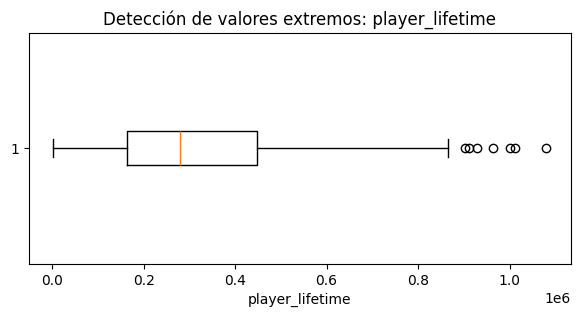

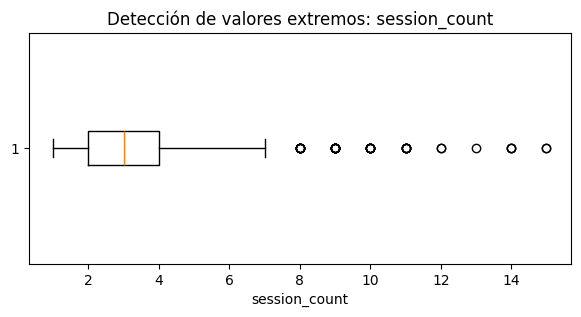

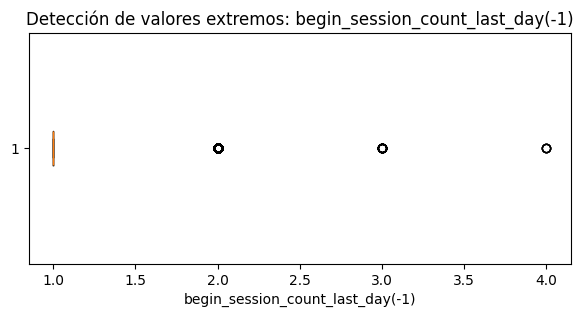

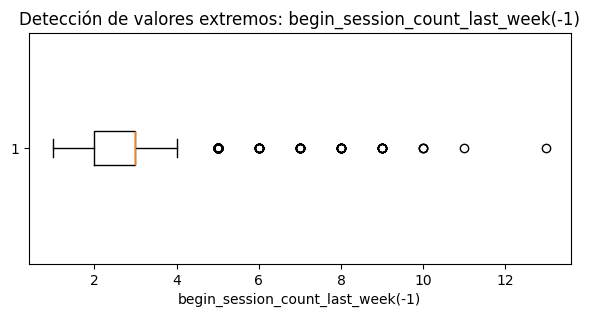

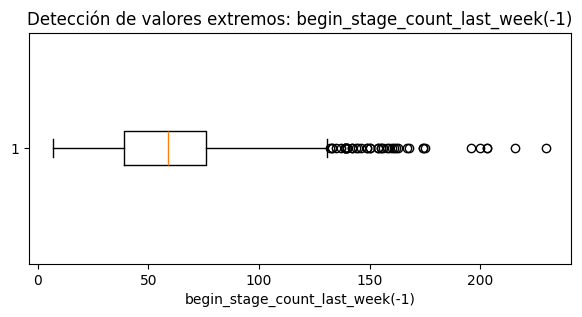

In [19]:
#Boxplots
for col in variables_revision:
    plt.figure(figsize=(7, 3))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Detección de valores extremos: {col}")
    plt.xlabel(col)
    plt.show()

In [20]:
#Resumen automático de outliers por IQR
outliers_resumen = []
for col in df.select_dtypes(include=np.number).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = df[
        (df[col] < limite_inferior) |
        (df[col] > limite_superior)
    ][col].count()
    outliers_resumen.append({
        "variable": col,
        "outliers": outliers,
        "porcentaje": round(outliers / len(df) * 100, 2)
    })
outliers_df = pd.DataFrame(outliers_resumen)
display(
    outliers_df
    .sort_values("porcentaje", ascending=False)
    .head(20)
)

,variable,outliers,porcentaje
16,end_session_count_last_day(-4),521,24.86
76,end_session_time_of_day_mean_last_day(-4),521,24.86
19,begin_session_count_last_day(-5),515,24.57
79,begin_session_time_of_day_mean_last_day(-5),515,24.57
81,begin_stage_time_of_day_mean_last_day(-5),514,24.52
82,end_stage_time_of_day_mean_last_day(-5),513,24.48
15,begin_session_count_last_day(-4),501,23.90
75,begin_session_time_of_day_mean_last_day(-4),501,23.90
77,begin_stage_time_of_day_mean_last_day(-4),499,23.81
78,end_stage_time_of_day_mean_last_day(-4),497,23.71


El criterio IQR identifica una proporción considerable de observaciones atípicas en diversas características de actividad.

Sin embargo, estas variables representan conteos y patrones de comportamiento de jugadores, por lo que es razonable encontrar diferencias importantes entre usuarios con distintos niveles de interacción.

En las variables revisadas no se detectaron rangos evidentemente imposibles. Por esta razón, los valores extremos no serán eliminados automáticamente y se conservarán durante el modelado.

Los modelos sensibles a la escala serán tratados posteriormente mediante estandarización.

### 3.5 Diagnóstico general de calidad

| Problema detectado | Variable afectada | Evidencia | Posible impacto | Tratamiento propuesto |
|---|---|---|---|---|
| Valores faltantes | 42 variables `std` | 11,231 valores faltantes | Algunos algoritmos no admiten NaN directamente | Imputación por mediana dentro del pipeline |
| Registros duplicados | Dataset completo | 0 registros duplicados | No se detecta repetición artificial de observaciones | No requiere tratamiento |
| Variables constantes | 24 variables | Un único valor en todas las observaciones | No aportan capacidad discriminativa | Excluir del modelado |
| Variables casi constantes | 15 variables | Valor dominante ≥95% | Posible baja utilidad predictiva | Conservar inicialmente y evaluar posteriormente |
| Identificador único | `player_id` | 2,096 valores únicos | Riesgo de memorizar jugadores | Excluir |
| Posible leakage | `player_type` | Asociación fuerte con churn y origen sintético | Puede inflar artificialmente el desempeño | Excluir |
| Posible artefacto temporal | `cohort_id` | Grandes diferencias de churn entre cohortes | Riesgo de dependencia temporal no generalizable | Excluir |
| Desbalance de clases | `player_churn` | 56.01% no churn y 43.99% churn | Accuracy aislada puede ser engañosa | Estratificación y evaluación con múltiples métricas |
| Valores extremos | Variables numéricas de actividad | Diversas columnas presentan outliers por IQR | Posible sensibilidad en modelos basados en escala | Conservar al no existir evidencia de error y aplicar escalamiento |
| Categorías inconsistentes | Variables categóricas | Verificación específica de espacios y categorías normalizadas | Podría crear categorías artificialmente diferentes | Normalizar únicamente si se detectan inconsistencias |
| Numéricas almacenadas como texto | Variables tipo `object` | Verificación mediante conversión numérica | Podría impedir un tratamiento numérico adecuado | Convertir solo si la auditoría confirma el problema |

## 4. Análisis exploratorio de datos (EDA)

El análisis exploratorio busca identificar patrones de comportamiento relacionados con el abandono antes de construir los modelos.

Se estudian características representativas de permanencia, actividad acumulada, actividad reciente, perfil del jugador y cohorte, además de relaciones entre variables numéricas.


In [21]:
#Siguiente bloque: EDA
#Vamos a estudiar variables que representan aspectos distintos del comportamiento del jugador:
#player_lifetime → antigüedad/tiempo de vida.
#session_count → actividad global.
#begin_session_count_last_day(-1) → actividad reciente.

In [22]:
#Estadísticas según churn
variables_eda = [
    "player_lifetime",
    "session_count",
    "begin_session_count_last_day(-1)"
]
estadisticas_churn = df.groupby("player_churn")[variables_eda].agg(
    ["mean", "median", "std"]
).round(2)
display(estadisticas_churn)

player_lifetime                       session_count               \
                        mean     median        std          mean median   std   
player_churn                                                                    
False              387302.18  353413.29  200114.70          3.49    3.0  1.77   
True               208172.08  179085.94  186461.92          2.33    2.0  1.17   

             begin_session_count_last_day(-1)               
                                         mean median   std  
player_churn                                                
False                                    1.21    1.0  0.47  
True                                     1.11    1.0  0.31

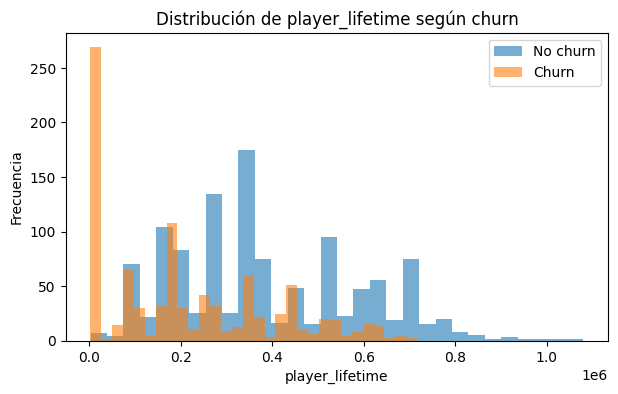

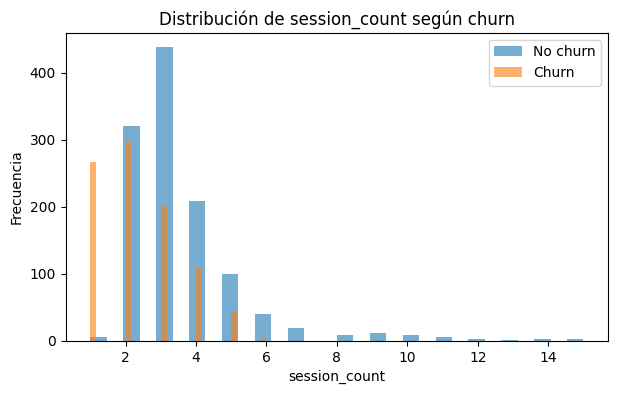

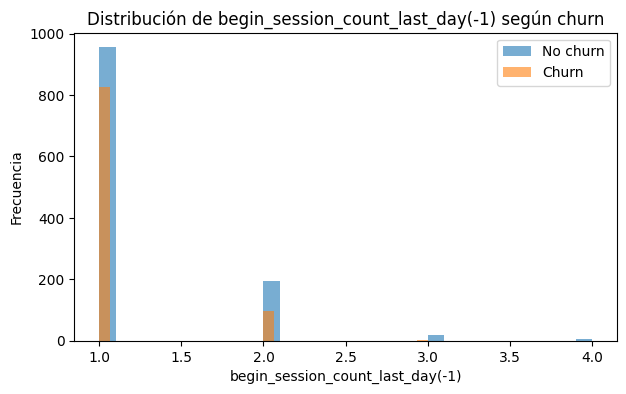

In [23]:
#Distribución de variables numéricas
for variable in variables_eda:
    plt.figure(figsize=(7, 4))
    plt.hist(
        df[df["player_churn"] == False][variable],
        bins=30,
        alpha=0.6,
        label="No churn"
    )
    plt.hist(
        df[df["player_churn"] == True][variable],
        bins=30,
        alpha=0.6,
        label="Churn"
    )
    plt.title(f"Distribución de {variable} según churn")
    plt.xlabel(variable)
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.show()

,jugadores,jugadores_churn,tasa_churn
segmento_sesion,,,
Dos o más sesiones,1823,655,35.93
Una sola sesión,273,267,97.80


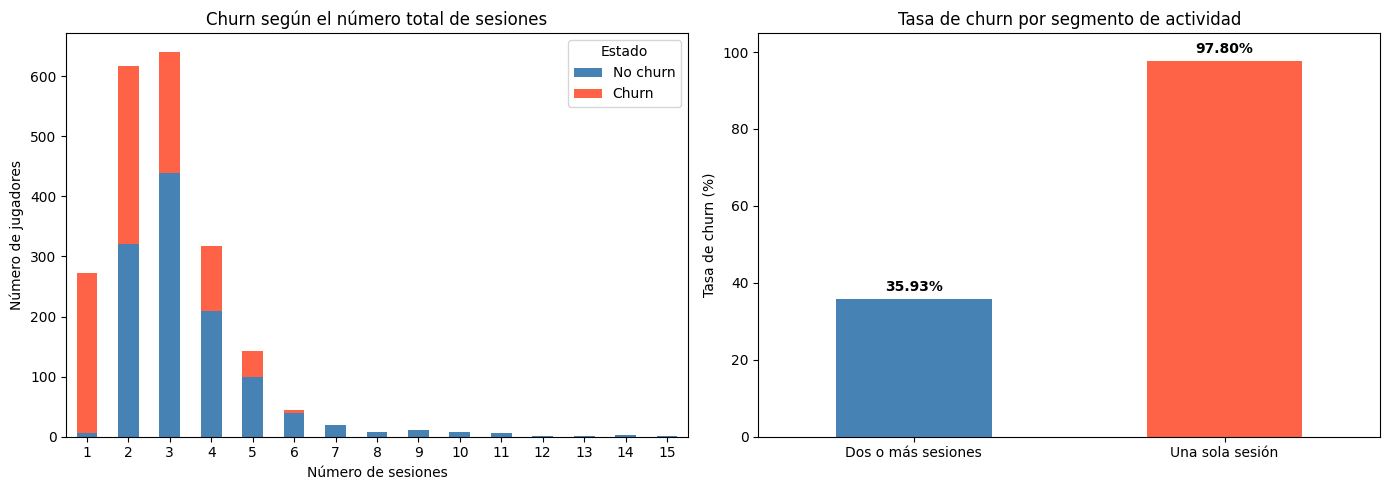

In [24]:
# Análisis de abandono según el número de sesiones

# Distribución de jugadores por número de sesiones y churn
sesiones_churn = pd.crosstab(
    df["session_count"],
    df["player_churn"]
).reindex(columns=[False, True], fill_value=0)

sesiones_churn.columns = ["No churn", "Churn"]

# Separar abandono inmediato de jugadores que regresaron
segmento_sesion = np.where(
    df["session_count"] == 1,
    "Una sola sesión",
    "Dos o más sesiones"
)

resumen_segmentos = (
    df.assign(segmento_sesion=segmento_sesion)
      .groupby("segmento_sesion")
      .agg(
          jugadores=("player_churn", "size"),
          jugadores_churn=("player_churn", "sum"),
          tasa_churn=("player_churn", "mean")
      )
)

resumen_segmentos["tasa_churn"] *= 100

display(resumen_segmentos.round(2))

# Visualización conjunta
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sesiones_churn.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=["steelblue", "tomato"]
)

axes[0].set_title("Churn según el número total de sesiones")
axes[0].set_xlabel("Número de sesiones")
axes[0].set_ylabel("Número de jugadores")
axes[0].legend(title="Estado")
axes[0].tick_params(axis="x", rotation=0)

resumen_segmentos["tasa_churn"].plot(
    kind="bar",
    ax=axes[1],
    color=["steelblue", "tomato"]
)

axes[1].set_title("Tasa de churn por segmento de actividad")
axes[1].set_xlabel("")
axes[1].set_ylabel("Tasa de churn (%)")
axes[1].set_ylim(0, 105)
axes[1].tick_params(axis="x", rotation=0)

for i, valor in enumerate(resumen_segmentos["tasa_churn"]):
    axes[1].text(
        i,
        valor + 2,
        f"{valor:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### 4.1 Segmentación del abandono según el número de sesiones

> Añadir blockquote




1.   Elemento de lista
2.   Elemento de lista


La distribución de `session_count` muestra que el abandono no constituye un único fenómeno. De los 273 jugadores que registraron una sola sesión, 267 presentan churn, lo que representa una tasa de abandono de aproximadamente 97.80%.

En contraste, entre los 1,823 jugadores que registraron dos o más sesiones, la tasa de churn disminuye a aproximadamente 35.93%.

Esto indica la existencia de dos comportamientos distintos:

- **abandono inmediato:** jugadores que no regresan después de su primera sesión;
- **churn posterior:** jugadores que inicialmente continúan participando, pero abandonan después de haber acumulado más actividad.

Analizar ambos grupos como si representaran el mismo comportamiento podría provocar que el modelo dependa excesivamente de `session_count` y oculte las variables asociadas con el abandono de jugadores que ya habían mostrado cierto nivel de permanencia.

Por esta razón, ambos segmentos se analizarán por separado y, antes del entrenamiento, se definirá la población correspondiente al problema predictivo.

,Estadística,Valor
0,Media,2.98
1,Desviación estándar,1.64
2,Media + 1 desviación,4.61
3,Media + 3 desviaciones,7.89
4,Máximo,15.00
5,Distancia del máximo en desviaciones,7.34


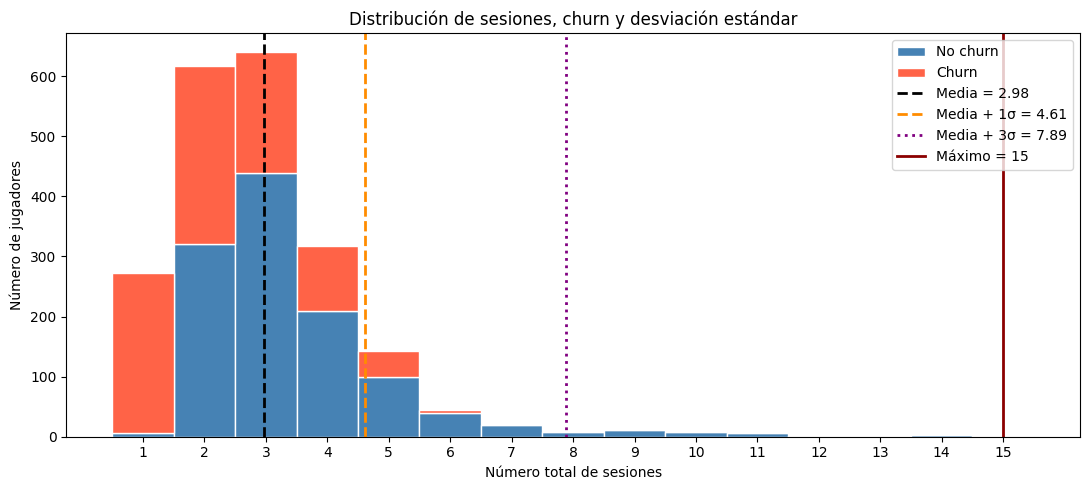

In [25]:
# Dispersión y valor extremo de session_count

media_sesiones = df["session_count"].mean()
desviacion_sesiones = df["session_count"].std()
maximo_sesiones = df["session_count"].max()

limite_1_std = media_sesiones + desviacion_sesiones
limite_3_std = media_sesiones + (3 * desviacion_sesiones)

distancia_maximo_std = (
    (maximo_sesiones - media_sesiones)
    / desviacion_sesiones
)

resumen_dispersion = pd.DataFrame({
    "Estadística": [
        "Media",
        "Desviación estándar",
        "Media + 1 desviación",
        "Media + 3 desviaciones",
        "Máximo",
        "Distancia del máximo en desviaciones"
    ],
    "Valor": [
        media_sesiones,
        desviacion_sesiones,
        limite_1_std,
        limite_3_std,
        maximo_sesiones,
        distancia_maximo_std
    ]
})

display(resumen_dispersion.round(2))

# Histograma con medidas de dispersión
bins_sesiones = np.arange(
    df["session_count"].min() - 0.5,
    df["session_count"].max() + 1.5,
    1
)

plt.figure(figsize=(11, 5))

plt.hist(
    [
        df.loc[df["player_churn"] == False, "session_count"],
        df.loc[df["player_churn"] == True, "session_count"]
    ],
    bins=bins_sesiones,
    stacked=True,
    color=["steelblue", "tomato"],
    label=["No churn", "Churn"],
    edgecolor="white"
)

plt.axvline(
    media_sesiones,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Media = {media_sesiones:.2f}"
)

plt.axvline(
    limite_1_std,
    color="darkorange",
    linestyle="--",
    linewidth=2,
    label=f"Media + 1σ = {limite_1_std:.2f}"
)

plt.axvline(
    limite_3_std,
    color="purple",
    linestyle=":",
    linewidth=2,
    label=f"Media + 3σ = {limite_3_std:.2f}"
)

plt.axvline(
    maximo_sesiones,
    color="darkred",
    linestyle="-",
    linewidth=2,
    label=f"Máximo = {maximo_sesiones}"
)

plt.title("Distribución de sesiones, churn y desviación estándar")
plt.xlabel("Número total de sesiones")
plt.ylabel("Número de jugadores")
plt.xticks(range(1, int(maximo_sesiones) + 1))
plt.legend()
plt.tight_layout()
plt.show()

### 4.2 Dispersión y valores extremos en el número de sesiones

`session_count` presenta una media aproximada de 2.98 sesiones y una desviación estándar de 1.64. Esto indica que la cantidad de sesiones se concentra principalmente alrededor de valores relativamente bajos.

El valor máximo es de 15 sesiones y se encuentra aproximadamente 7.34 desviaciones estándar por encima de la media. Por lo tanto, puede considerarse un valor estadísticamente extremo dentro de la distribución.

Sin embargo, un valor estadísticamente extremo no representa automáticamente un error. En este caso, 15 sesiones constituye un comportamiento posible para un jugador con mayor permanencia y no un rango imposible para la variable. Por ello, el registro se conserva.

La desviación estándar permite contextualizar la distancia respecto de la media, pero no debe utilizarse aisladamente para eliminar observaciones, especialmente porque `session_count` presenta una distribución asimétrica y no una distribución normal.

### 4.3 Características numéricas y churn

*   Elemento de lista

*   Elemento de lista
*   Elemento de lista


*   Elemento de lista



1.   Elemento de lista
2.   Elemento de lista



Las diferencias más evidentes aparecen en `player_lifetime` y `session_count`.

Los jugadores sin churn presentan un `player_lifetime` medio aproximado de 387,302, mientras que los jugadores con churn presentan una media cercana a 208,172. Las medianas siguen el mismo patrón.

También existe una diferencia en `session_count`: los jugadores sin churn presentan una media aproximada de 3.49 sesiones frente a 2.33 entre aquellos con churn.

En `begin_session_count_last_day(-1)` la diferencia es menor, con medias aproximadas de 1.21 y 1.11 respectivamente.

Estos resultados sugieren que la permanencia y la actividad acumulada ofrecen inicialmente una separación más clara entre clases que una única medida de actividad diaria. Las relaciones observadas representan asociaciones y no implican causalidad.

In [26]:
#player_type vs churn
tabla_player_type = pd.crosstab(
    df["player_type"],
    df["player_churn"],
    margins=True
)
display(tabla_player_type)
print("\nPorcentaje de churn dentro de cada player_type:")
display(
    pd.crosstab(
        df["player_type"],
        df["player_churn"],
        normalize="index"
    ).mul(100).round(2)
)

player_churn,False,True,All
player_type,,,
casual,95,19,114
churner,994,903,1897
hardcore,85,0,85
All,1174,922,2096



Porcentaje de churn dentro de cada player_type:


player_churn,False,True
player_type,,
casual,83.33,16.67
churner,52.40,47.60
hardcore,100.00,0.00


In [27]:
#Cohortes vs churn
cohort_churn = pd.crosstab(
    df["cohort_id"],
    df["player_churn"],
    normalize="index"
).mul(100).round(2)
display(cohort_churn)

player_churn,False,True
cohort_id,,
2023_01_01,100.00,0.00
2023_01_02,100.00,0.00
2023_01_03,36.90,63.10
2023_01_04,39.04,60.96
2023_01_05,47.67,52.33
2023_01_06,50.70,49.30
2023_01_07,60.00,40.00
2023_01_08,63.15,36.85
2023_01_09,70.77,29.23


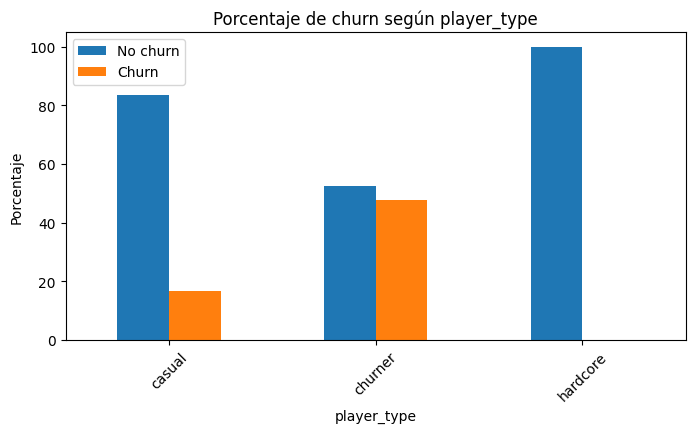

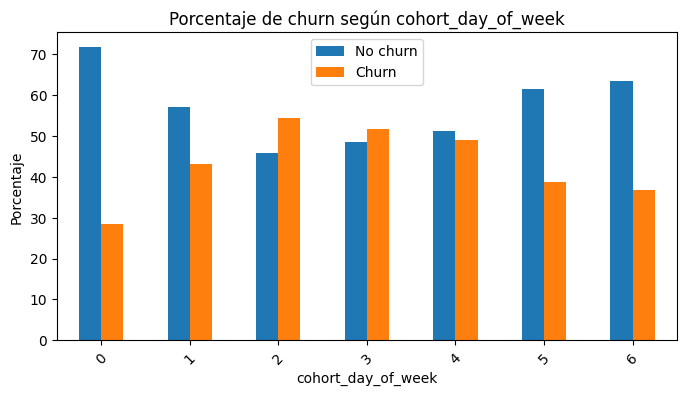

In [28]:
#Categóricas vs churn
for variable in ["player_type", "cohort_day_of_week"]:
    tabla = pd.crosstab(
        df[variable],
        df["player_churn"],
        normalize="index"
    ).mul(100)
    tabla.plot(
        kind="bar",
        figsize=(8, 4)
    )
    plt.title(f"Porcentaje de churn según {variable}")
    plt.xlabel(variable)
    plt.ylabel("Porcentaje")
    plt.xticks(rotation=45)
    plt.legend(["No churn", "Churn"])
    plt.show()

### 4.4 Variables categóricas y temporales

*   Elemento de lista
*   Elemento de lista



`player_type` presenta diferencias importantes en la proporción de churn. Los jugadores `casual` muestran aproximadamente 16.67% de churn, los clasificados como `churner` aproximadamente 47.60%, mientras que en la categoría `hardcore` no se observaron casos positivos.

También existen diferencias considerables entre los distintos valores de `cohort_id`. Algunas cohortes presentan tasas superiores al 50%, mientras que otras presentan valores considerablemente menores.

Aunque estas relaciones podrían resultar predictivamente útiles, también requieren precaución. Tanto `player_type` como `cohort_id` pueden reflejar características propias del mecanismo utilizado para generar u observar los datos y, por ello, serán revisadas específicamente antes de utilizarlas como predictores.

,player_lifetime,session_count,begin_session_count_last_day(-1),begin_session_count_last_week(-1),begin_stage_count_last_week(-1)
player_lifetime,1.00,0.75,0.02,0.63,0.63
session_count,0.75,1.00,0.30,0.94,0.87
begin_session_count_last_day(-1),0.02,0.30,1.00,0.35,0.27
begin_session_count_last_week(-1),0.63,0.94,0.35,1.00,0.93
begin_stage_count_last_week(-1),0.63,0.87,0.27,0.93,1.00


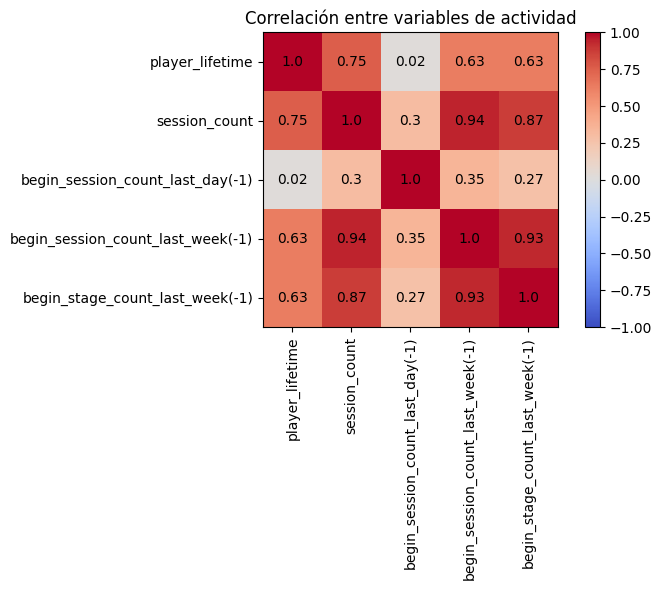

In [29]:
#Correlación entre variables numéricas seleccionadas
variables_correlacion = [
    "player_lifetime",
    "session_count",
    "begin_session_count_last_day(-1)",
    "begin_session_count_last_week(-1)",
    "begin_stage_count_last_week(-1)"
]
correlacion = df[variables_correlacion].corr().round(2)
display(correlacion)
plt.figure(figsize=(8, 6))
plt.imshow(correlacion, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(
    range(len(correlacion.columns)),
    correlacion.columns,
    rotation=90
)
plt.yticks(
    range(len(correlacion.columns)),
    correlacion.columns
)
for i in range(len(correlacion)):
    for j in range(len(correlacion)):
        plt.text(
            j, i,
            correlacion.iloc[i, j],
            ha="center",
            va="center"
        )
plt.title("Correlación entre variables de actividad")
plt.tight_layout()
plt.show()

### 4.5 Relaciones entre variables numéricas

Varias características de telemetría presentan relaciones entre sí. Este comportamiento es esperable debido a que numerosas columnas representan diferentes ventanas temporales o agregaciones de actividades relacionadas.

La existencia de correlación puede indicar información redundante entre algunas características.

En esta primera fase no se eliminarán variables únicamente por presentar correlación, ya que hacerlo sin evaluar su efecto sobre el desempeño podría eliminar información útil. La selección y reducción de características se considera una posible mejora para etapas posteriores.

### 4.6 Perfil exploratorio asociado con churn

1.   Elemento de lista
2.   Elemento de lista



Los resultados del EDA permiten identificar un perfil inicial asociado con mayor presencia de churn:

- menor permanencia del jugador;
- menor cantidad acumulada de sesiones;
- actividad reciente ligeramente menor.

Las diferencias observadas en permanencia y actividad acumulada son más pronunciadas que las encontradas al considerar únicamente la actividad de un día.

Este perfil no constituye una regla determinista. El objetivo de los modelos será combinar múltiples características para estimar el riesgo de abandono.

In [30]:
# Definición de la población para el modelado

# Los jugadores de una sola sesión permanecen en el EDA,
# pero se excluyen del modelo de churn posterior.
df_modelado = df.loc[df["session_count"] > 1].copy()

comparacion_poblaciones = pd.DataFrame({
    "Población": [
        "Dataset completo",
        "Una sola sesión",
        "Dos o más sesiones"
    ],
    "Jugadores": [
        len(df),
        (df["session_count"] == 1).sum(),
        len(df_modelado)
    ],
    "Jugadores con churn": [
        df["player_churn"].sum(),
        df.loc[
            df["session_count"] == 1,
            "player_churn"
        ].sum(),
        df_modelado["player_churn"].sum()
    ],
    "Tasa de churn (%)": [
        df["player_churn"].mean() * 100,
        df.loc[
            df["session_count"] == 1,
            "player_churn"
        ].mean() * 100,
        df_modelado["player_churn"].mean() * 100
    ]
})

display(comparacion_poblaciones.round(2))

print("Dimensiones originales:", df.shape)
print("Dimensiones para modelado:", df_modelado.shape)

,Población,Jugadores,Jugadores con churn,Tasa de churn (%)
0,Dataset completo,2096,922,43.99
1,Una sola sesión,273,267,97.80
2,Dos o más sesiones,1823,655,35.93


Dimensiones originales: (2096, 187)
Dimensiones para modelado: (1823, 187)


### 4.7 Definición de la población predictiva

El análisis exploratorio mostró que los jugadores con una sola sesión presentan una tasa de churn cercana al 97.80%. En este segmento, el número de sesiones prácticamente determina el resultado observado, por lo que mezclarlo con jugadores que regresaron podría dominar el aprendizaje del modelo y ocultar otros patrones de abandono.

Por esta razón, el modelo de esta fase se enfocará en el **churn posterior**, definido como el abandono de jugadores que registraron al menos dos sesiones.

Los 273 jugadores de una sola sesión no se eliminan del análisis general. Se conservan como un segmento de abandono inmediato, pero se excluyen de la población utilizada para entrenar el modelo de churn posterior.

Después del filtro, la población predictiva contiene 1,823 jugadores, de los cuales 655 presentan churn, equivalentes aproximadamente al 35.93%.

Esta decisión cambia el alcance del modelo: sus predicciones estarán dirigidas a jugadores que ya regresaron al juego al menos una vez. El abandono después de la primera sesión constituye un problema predictivo diferente, que requeriría variables medidas exclusivamente durante esa primera experiencia.

## 5. Análisis de leakage y selección de predictores

Antes de definir `X` e `y`, se revisan las características que podrían introducir información poco generalizable o una posible fuga de información.

### `player_id`

`player_id` identifica de forma única a cada jugador. No representa una característica de comportamiento generalizable y su inclusión podría permitir al modelo aprender asociaciones específicas de individuos. Por esta razón se excluye.

### `player_type`

Aunque `player_type` presenta una asociación importante con churn, el dataset es sintético y esta variable representa un perfil utilizado en el proceso de generación de jugadores.

Por lo tanto, existe riesgo de que codifique indirectamente parte del mecanismo que genera el comportamiento relacionado con churn. Utilizarla podría producir una estimación demasiado optimista del desempeño y reducir la aplicabilidad del modelo en un entorno real. Se excluye del modelado inicial.

### `cohort_id`

`cohort_id` identifica directamente la cohorte temporal del jugador. El EDA mostró diferencias pronunciadas en churn entre cohortes.

Estas diferencias pueden estar relacionadas con el momento de observación y con la cantidad de tiempo disponible para que ocurra el evento de churn, generando un posible artefacto temporal. Para evitar que el modelo dependa directamente de una cohorte específica, `cohort_id` se excluye.

Se conserva `cohort_day_of_week`, ya que representa una característica temporal generalizable y no identifica directamente una cohorte concreta.

### Variables constantes

Las 24 variables constantes identificadas anteriormente se eliminan debido a que presentan varianza cero y no aportan capacidad predictiva.

### Variables históricas de actividad

Las características basadas en sesiones, stages y ventanas temporales se conservan bajo el supuesto de que representan información histórica disponible antes del momento de realizar la predicción.

Estas variables serían válidas siempre que en un sistema real se calculen exclusivamente con actividad ocurrida antes del instante de inferencia.

### Conclusión

Para esta primera fase se excluyen:

- `player_id`;
- `player_type`;
- `cohort_id`;
- las 24 variables constantes.

La variable `player_churn` se separará como objetivo y no será utilizada como predictor.

Esta decisión busca reducir el riesgo de fuga de información y obtener una estimación de desempeño más representativa de un escenario de inferencia real.

In [31]:
# Evaluación de las columnas consideradas para exclusión

# Las variables constantes deben calcularse nuevamente
# sobre la población que realmente será modelada.
columnas_constantes_modelado = [
    col for col in df_modelado.columns
    if df_modelado[col].nunique(dropna=False) <= 1
]

# Asociación observada con churn
churn_por_player_type = (
    df_modelado.groupby("player_type")["player_churn"]
    .mean()
    .mul(100)
)

churn_por_cohorte = (
    df_modelado.groupby("cohort_id")["player_churn"]
    .mean()
    .mul(100)
)

churn_por_dia = (
    df_modelado.groupby("cohort_day_of_week")["player_churn"]
    .mean()
    .mul(100)
)

revision_predictores = pd.DataFrame({
    "Variable o grupo": [
        "player_id",
        "player_churn",
        "player_type",
        "cohort_id",
        "Variables constantes",
        "cohort_day_of_week",
        "Variables históricas de actividad"
    ],
    "Evidencia": [
        (
            f"{df_modelado['player_id'].nunique()} valores únicos "
            f"en {len(df_modelado)} jugadores"
        ),
        "Variable binaria que representa el resultado",
        (
            f"Tasa de churn entre "
            f"{churn_por_player_type.min():.2f}% y "
            f"{churn_por_player_type.max():.2f}%"
        ),
        (
            f"Tasa de churn entre "
            f"{churn_por_cohorte.min():.2f}% y "
            f"{churn_por_cohorte.max():.2f}%"
        ),
        f"{len(columnas_constantes_modelado)} columnas con varianza cero",
        (
            f"Tasa de churn entre "
            f"{churn_por_dia.min():.2f}% y "
            f"{churn_por_dia.max():.2f}%"
        ),
        "Conteos, permanencia y actividad en diferentes ventanas temporales"
    ],
    "Relación con el objetivo": [
        "No interpretable: cada identificador aparece una sola vez",
        "Define directamente la clase que se intenta predecir",
        "Asociación fuerte, pero puede provenir del generador sintético",
        "Asociación temporal que puede depender del periodo observado",
        "Ninguna: presentan el mismo valor en todos los jugadores",
        "Puede representar un patrón temporal generalizable",
        "Representan el comportamiento observable del jugador"
    ],
    "Decisión": [
        "Excluir",
        "Separar como y",
        "Excluir por riesgo de leakage conceptual",
        "Excluir por posible artefacto temporal",
        "Excluir",
        "Conservar",
        "Conservar"
    ]
})

display(revision_predictores)

,Variable o grupo,Evidencia,Relación con el objetivo,Decisión
0,player_id,1823 valores únicos en 1823 jugadores,No interpretable: cada identificador aparece u...,Excluir
1,player_churn,Variable binaria que representa el resultado,Define directamente la clase que se intenta pr...,Separar como y
2,player_type,Tasa de churn entre 0.00% y 39.13%,"Asociación fuerte, pero puede provenir del gen...",Excluir por riesgo de leakage conceptual
3,cohort_id,Tasa de churn entre 0.00% y 63.10%,Asociación temporal que puede depender del per...,Excluir por posible artefacto temporal
4,Variables constantes,24 columnas con varianza cero,Ninguna: presentan el mismo valor en todos los...,Excluir
5,cohort_day_of_week,Tasa de churn entre 18.64% y 52.85%,Puede representar un patrón temporal generaliz...,Conservar
6,Variables históricas de actividad,"Conteos, permanencia y actividad en diferentes...",Representan el comportamiento observable del j...,Conservar


In [32]:
# Construcción de X e y a partir de la población seleccionada

# Columnas que no funcionarán como predictores
columnas_excluir = [
    "player_id",
    "player_type",
    "cohort_id"
] + columnas_constantes_modelado

# Eliminar posibles nombres repetidos conservando el orden
columnas_excluir = list(dict.fromkeys(columnas_excluir))

# El drop de variables no relevantes ocurre aquí
X = df_modelado.drop(
    columns=columnas_excluir + ["player_churn"]
)

# La variable objetivo se separa de los predictores
y = df_modelado["player_churn"].astype(int)

print("Jugadores utilizados para modelado:", len(df_modelado))
print("Columnas originales:", df_modelado.shape[1])
print("Columnas excluidas como predictores:", len(columnas_excluir))
print("Variables predictoras finales:", X.shape[1])
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

print("\nDistribución de la variable objetivo:")
print(y.value_counts())

print("\nDistribución porcentual:")
print(
    y.value_counts(normalize=True)
     .mul(100)
     .round(2)
)

print("\nComprobaciones:")
print("player_churn está en X:", "player_churn" in X.columns)
print(
    "Columnas excluidas todavía presentes:",
    [col for col in columnas_excluir if col in X.columns]
)

Jugadores utilizados para modelado: 1823
Columnas originales: 187
Columnas excluidas como predictores: 27
Variables predictoras finales: 159
Dimensiones de X: (1823, 159)
Dimensiones de y: (1823,)

Distribución de la variable objetivo:
player_churn
0    1168
1     655
Name: count, dtype: int64

Distribución porcentual:
player_churn
0    64.07
1    35.93
Name: proportion, dtype: float64

Comprobaciones:
player_churn está en X: False
Columnas excluidas todavía presentes: []


Después de las exclusiones, el conjunto de predictores queda compuesto por **159 características**.

La variable objetivo `player_churn` se transforma a representación binaria:

- `0`: no churn.
- `1`: churn.

De esta manera, churn permanece como clase positiva durante toda la evaluación.

## 6. División de los datos

Los datos se dividen en tres subconjuntos independientes:

- **70% entrenamiento**
- **15% validación**
- **15% prueba**

Se utiliza `random_state=42` para garantizar reproducibilidad y `stratify` para mantener aproximadamente la misma proporción de churn en cada subconjunto.

El conjunto de entrenamiento será utilizado para ajustar los modelos, el conjunto de validación para comparar alternativas y seleccionar configuraciones preliminares, mientras que el conjunto de prueba permanecerá sin utilizar durante esta fase para evitar contaminar la evaluación final.

In [33]:
#Split 70/15/15
#Primero separamos 70% entrenamiento y dejamos 30%; después dividimos ese 30% por la mitad.
from sklearn.model_selection import train_test_split
# 70% entrenamiento, 30% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)
# Dividir el 30% restante en 15% validación y 15% prueba
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (1276, 159) (1276,)
Validation: (273, 159) (273,)
Test: (274, 159) (274,)


In [34]:
#Verificar estratificación
for nombre, target in [
    ("Train", y_train),
    ("Validation", y_val),
    ("Test", y_test)
]:
    print(f"\n{nombre}")
    print(
        target.value_counts(normalize=True)
        .mul(100)
        .round(2)
    )


Train
player_churn
0    64.11
1    35.89
Name: proportion, dtype: float64

Validation
player_churn
0    64.1
1    35.9
Name: proportion, dtype: float64

Test
player_churn
0    63.87
1    36.13
Name: proportion, dtype: float64


La división de la población seleccionada produjo:

- entrenamiento: 1,276 jugadores;
- validación: 273 jugadores;
- prueba: 274 jugadores.

La proporción de churn se mantiene cercana al 36% en los tres subconjuntos, confirmando que la estratificación funcionó correctamente.

La división se realizó después de excluir del modelado a los jugadores de una sola sesión. Por lo tanto, los tres subconjuntos representan exclusivamente a jugadores que regresaron al juego al menos una vez.

El conjunto de prueba permanecerá aislado y no se utilizará para seleccionar modelos, ajustar hiperparámetros ni modificar el umbral de clasificación durante esta fase.

## 7. Preprocesamiento reproducible

El preprocesamiento se construye utilizando `Pipeline` y `ColumnTransformer` para garantizar que todas las transformaciones sean aprendidas exclusivamente a partir del conjunto de entrenamiento.

Las variables numéricas reciben:

1. imputación por mediana para tratar valores faltantes;
2. estandarización mediante `StandardScaler`.

Las variables categóricas reciben:

1. imputación por la categoría más frecuente;
2. codificación One-Hot mediante `OneHotEncoder(handle_unknown="ignore")`.

Aunque `cohort_day_of_week` está almacenada como entero, representa una categoría y no una magnitud continua, por lo que se trata explícitamente como variable categórica.

Este enfoque previene leakage durante el preprocesamiento y permite aplicar exactamente las mismas transformaciones durante validación, prueba e inferencia futura.

In [35]:
#Identificar variables numéricas y categóricas
columnas_numericas = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()
columnas_categoricas = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()
print("Variables numéricas:", len(columnas_numericas))
print("Variables categóricas:", len(columnas_categoricas))
print("\nVariables categóricas:")
print(columnas_categoricas)

Variables numéricas: 159
Variables categóricas: 0

Variables categóricas:
[]


In [36]:
#Tratar día de la semana como categórica
# cohort_day_of_week representa categorías, no una magnitud continua
columnas_numericas.remove("cohort_day_of_week")
columnas_categoricas.append("cohort_day_of_week")
print("Variables numéricas finales:", len(columnas_numericas))
print("Variables categóricas finales:", len(columnas_categoricas))
print("\nCategóricas:")
print(columnas_categoricas)

Variables numéricas finales: 158
Variables categóricas finales: 1

Categóricas:
['cohort_day_of_week']


In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
pipeline_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
pipeline_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocesador = ColumnTransformer([
    ("num", pipeline_numerico, columnas_numericas),
    ("cat", pipeline_categorico, columnas_categoricas)
])
print("Preprocesador creado correctamente.")

Preprocesador creado correctamente.


## 8. Línea base

Antes de entrenar modelos reales se establece una referencia mediante `DummyClassifier`.

El baseline utiliza la estrategia de predecir siempre la clase mayoritaria. Su finalidad no es obtener un modelo útil, sino establecer el nivel mínimo que cualquier clasificador real debe superar.

In [38]:
#establecer una referencia antes de evaluar modelos reales.
#DummyClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
modelo_dummy = Pipeline([
    ("preprocesador", preprocesador),
    ("modelo", DummyClassifier(
        strategy="most_frequent",
        random_state=42
    ))
])
modelo_dummy.fit(X_train, y_train)
y_val_pred_dummy = modelo_dummy.predict(X_val)
y_val_prob_dummy = modelo_dummy.predict_proba(X_val)[:, 1]
print("DummyClassifier - Validación")
print("--------------------------------")
print("Accuracy :", round(accuracy_score(y_val, y_val_pred_dummy), 4))
print("Precision:", round(precision_score(y_val, y_val_pred_dummy, zero_division=0), 4))
print("Recall   :", round(recall_score(y_val, y_val_pred_dummy, zero_division=0), 4))
print("F1       :", round(f1_score(y_val, y_val_pred_dummy, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_val, y_val_prob_dummy), 4))

DummyClassifier - Validación
--------------------------------
Accuracy : 0.641
Precision: 0.0
Recall   : 0.0
F1       : 0.0
ROC-AUC  : 0.5


El DummyClassifier obtiene aproximadamente **64.10% de accuracy**, pero presenta precision, recall y F1 iguales a cero para la clase churn, además de un ROC-AUC de 0.50.

El aumento del accuracy respecto del análisis anterior se debe a que, después de excluir a los jugadores de una sola sesión, la clase sin churn representa aproximadamente el 64.07% de la población modelada.

A pesar de este accuracy, el modelo no identifica correctamente ningún jugador con churn: clasifica los 273 casos de validación como no churn y genera 98 falsos negativos.

Esto confirma que accuracy no debe utilizarse de forma aislada y establece el desempeño mínimo que los modelos reales deben superar.

## 9. Modelos iniciales

Se entrenan dos modelos iniciales utilizando exactamente los mismos conjuntos de datos y el mismo pipeline de preprocesamiento:

- Regresión Logística.
- Árbol de Decisión.

La Regresión Logística proporciona una referencia lineal interpretable, mientras que el Árbol de Decisión permite capturar relaciones no lineales entre las características.

No se realiza optimización extensa de hiperparámetros durante esta fase.

### 9.1 Métricas de evaluación

Los modelos se evaluarán mediante varias métricas complementarias:

- **Accuracy:** proporción total de predicciones correctas. Puede ser engañosa cuando existe diferencia en la frecuencia de las clases.
- **Precision:** proporción de jugadores clasificados como churn que realmente pertenecen a la clase positiva. Una precision baja implica mayor cantidad de falsas alertas.
- **Recall:** proporción de jugadores que realmente presentan churn y que son detectados correctamente por el modelo. En un escenario de retención es especialmente importante porque un recall bajo implica perder jugadores que realmente abandonan.
- **F1-score:** media armónica entre precision y recall. Permite valorar el equilibrio entre detectar churn y limitar falsos positivos.
- **ROC-AUC:** mide la capacidad del modelo para separar ambas clases a través de diferentes umbrales de decisión.

Por esta razón, la selección del modelo no se realizará únicamente utilizando accuracy.

In [39]:
#Regresión logística
#La regresión logística será nuestro modelo lineal e interpretable.
from sklearn.linear_model import LogisticRegression
modelo_logistico = Pipeline([
    ("preprocesador", preprocesador),
    ("modelo", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])
modelo_logistico.fit(X_train, y_train)
y_val_pred_log = modelo_logistico.predict(X_val)
y_val_prob_log = modelo_logistico.predict_proba(X_val)[:, 1]
print("Logistic Regression - Validación")
print("--------------------------------")
print("Accuracy :", round(accuracy_score(y_val, y_val_pred_log), 4))
print("Precision:", round(precision_score(y_val, y_val_pred_log), 4))
print("Recall   :", round(recall_score(y_val, y_val_pred_log), 4))
print("F1       :", round(f1_score(y_val, y_val_pred_log), 4))
print("ROC-AUC  :", round(roc_auc_score(y_val, y_val_prob_log), 4))

Logistic Regression - Validación
--------------------------------
Accuracy : 0.7802
Precision: 0.7436
Recall   : 0.5918
F1       : 0.6591
ROC-AUC  : 0.8031


In [40]:
#Árbol de decisión
#Usaremos un árbol moderadamente limitado para tener un modelo no lineal comparable.
from sklearn.tree import DecisionTreeClassifier
modelo_arbol = Pipeline([
    ("preprocesador", preprocesador),
    ("modelo", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])
modelo_arbol.fit(X_train, y_train)
y_val_pred_arbol = modelo_arbol.predict(X_val)
y_val_prob_arbol = modelo_arbol.predict_proba(X_val)[:, 1]
print("Decision Tree - Validación")
print("--------------------------------")
print("Accuracy :", round(accuracy_score(y_val, y_val_pred_arbol), 4))
print("Precision:", round(precision_score(y_val, y_val_pred_arbol), 4))
print("Recall   :", round(recall_score(y_val, y_val_pred_arbol), 4))
print("F1       :", round(f1_score(y_val, y_val_pred_arbol), 4))
print("ROC-AUC  :", round(roc_auc_score(y_val, y_val_prob_arbol), 4))

Decision Tree - Validación
--------------------------------
Accuracy : 0.8205
Precision: 0.8182
Recall   : 0.6429
F1       : 0.72
ROC-AUC  : 0.7764


In [41]:
#Comparación conjunta
resultados = pd.DataFrame({
    "Modelo": [
        "DummyClassifier",
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_val, y_val_pred_dummy),
        accuracy_score(y_val, y_val_pred_log),
        accuracy_score(y_val, y_val_pred_arbol)
    ],
    "Precision": [
        precision_score(y_val, y_val_pred_dummy, zero_division=0),
        precision_score(y_val, y_val_pred_log),
        precision_score(y_val, y_val_pred_arbol)
    ],
    "Recall": [
        recall_score(y_val, y_val_pred_dummy, zero_division=0),
        recall_score(y_val, y_val_pred_log),
        recall_score(y_val, y_val_pred_arbol)
    ],
    "F1": [
        f1_score(y_val, y_val_pred_dummy, zero_division=0),
        f1_score(y_val, y_val_pred_log),
        f1_score(y_val, y_val_pred_arbol)
    ],
    "ROC_AUC": [
        roc_auc_score(y_val, y_val_prob_dummy),
        roc_auc_score(y_val, y_val_prob_log),
        roc_auc_score(y_val, y_val_prob_arbol)
    ]
})
display(
    resultados.set_index("Modelo").round(4)
)

,Accuracy,Precision,Recall,F1,ROC_AUC
Modelo,,,,,
DummyClassifier,0.6410,0.0000,0.0000,0.0000,0.5000
Logistic Regression,0.7802,0.7436,0.5918,0.6591,0.8031
Decision Tree,0.8205,0.8182,0.6429,0.7200,0.7764


### 9.2 Comparación en validación

Los resultados calculados automáticamente sobre el conjunto de validación son:

| Modelo | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| DummyClassifier | 0.6410 | 0.0000 | 0.0000 | 0.0000 | 0.5000 |
| Regresión Logística | 0.7802 | 0.7436 | 0.5918 | 0.6591 | 0.8031 |
| Árbol de Decisión | 0.8205 | 0.8182 | 0.6429 | 0.7200 | 0.7764 |

Con el threshold predeterminado de 0.50, el Árbol de Decisión presenta el mejor desempeño en accuracy, precision, recall y F1.

La Regresión Logística obtiene un ROC-AUC superior: 0.8031 frente a 0.7764. Esto indica que posee una mejor capacidad global para ordenar a los jugadores según su nivel de riesgo cuando se consideran diferentes umbrales, aunque su clasificación con threshold 0.50 es inferior a la del árbol.

Por lo tanto, el Árbol de Decisión constituye el modelo más fuerte con su configuración predeterminada, mientras que la Regresión Logística conserva potencial para mejorar la detección de churn mediante el ajuste de su umbral.

## 10. Análisis de errores

Además de las métricas agregadas, se revisan las matrices de confusión para analizar directamente falsos positivos y falsos negativos.

En el contexto de retención:

- un **falso positivo** representa un jugador estable clasificado como riesgo de churn, lo cual podría generar una intervención o incentivo innecesario;
- un **falso negativo** representa un jugador que realmente abandona pero que el modelo considera estable, por lo que podría perderse una oportunidad de retención.

Inicialmente, el falso negativo se considera el error más crítico, aunque aumentar excesivamente el recall también puede incrementar el costo producido por falsas alertas.

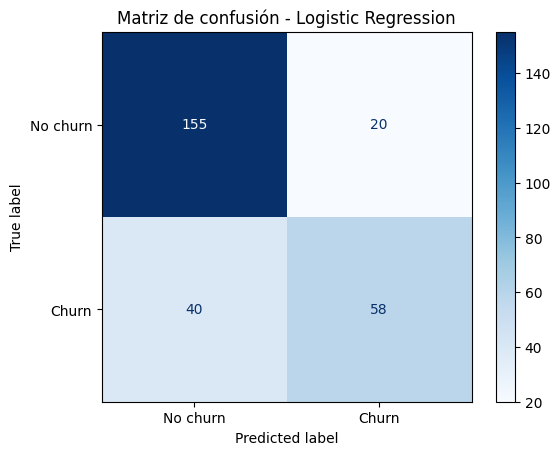

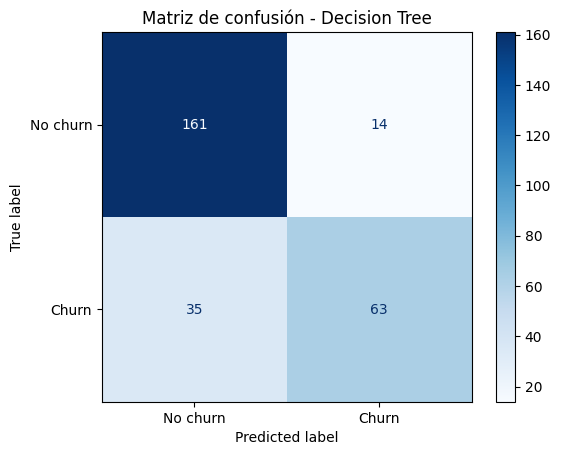

In [42]:
#Matrices de confusión
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
modelos_predicciones = {
    "Logistic Regression": y_val_pred_log,
    "Decision Tree": y_val_pred_arbol
}
for nombre, predicciones in modelos_predicciones.items():
    ConfusionMatrixDisplay.from_predictions(
        y_val,
        predicciones,
        display_labels=["No churn", "Churn"],
        cmap="Blues"
    )
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()

In [43]:
#Obtener TP, TN, FP y FN
from sklearn.metrics import confusion_matrix
for nombre, predicciones in modelos_predicciones.items():
    tn, fp, fn, tp = confusion_matrix(
        y_val,
        predicciones
    ).ravel()
    print(f"\n{nombre}")
    print("-------------------------")
    print("True Negatives :", tn)
    print("False Positives:", fp)
    print("False Negatives:", fn)
    print("True Positives :", tp)
#Aquí nos interesan especialmente los False Negatives:
#jugadores que realmente abandonaron pero el modelo clasificó como no churn.
#En un sistema de retención son peligrosos porque no recibirían una intervención cuando sí estaban en riesgo.


Logistic Regression
-------------------------
True Negatives : 155
False Positives: 20
False Negatives: 40
True Positives : 58

Decision Tree
-------------------------
True Negatives : 161
False Positives: 14
False Negatives: 35
True Positives : 63


<Figure size 700x600 with 0 Axes>

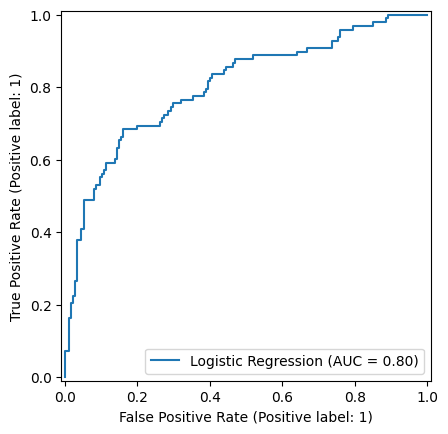

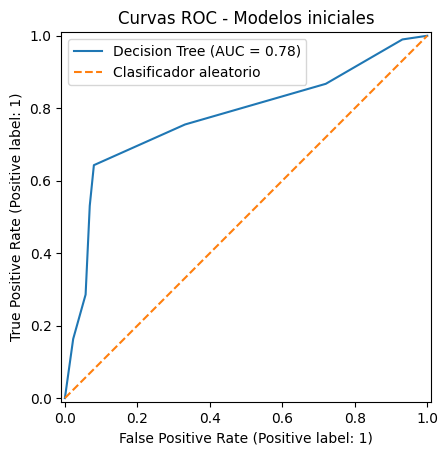

In [44]:
#Curvas ROC
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_val,
    y_val_prob_log,
    name="Logistic Regression"
)
RocCurveDisplay.from_predictions(
    y_val,
    y_val_prob_arbol,
    name="Decision Tree"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)
plt.title("Curvas ROC - Modelos iniciales")
plt.legend()
plt.show()

La Regresión Logística obtiene:

- 155 verdaderos negativos;
- 20 falsos positivos;
- 40 falsos negativos;
- 58 verdaderos positivos.

El Árbol de Decisión obtiene:

- 161 verdaderos negativos;
- 14 falsos positivos;
- 35 falsos negativos;
- 63 verdaderos positivos.

Con threshold 0.50, el Árbol de Decisión comete menos errores de ambos tipos. Reduce los falsos positivos de 20 a 14 y los falsos negativos de 40 a 35.

Esto explica por qué supera a la Regresión Logística en precision y recall con el umbral predeterminado. No obstante, la Regresión Logística genera probabilidades con un ROC-AUC superior, por lo que todavía puede modificarse su threshold para priorizar la detección de jugadores en riesgo.

## 11. Análisis del umbral de clasificación

Los clasificadores probabilísticos utilizan normalmente un umbral de 0.50 para transformar una probabilidad en una clase.

Sin embargo, este valor no necesariamente representa el mejor equilibrio para un problema de retención.

Se evalúan umbrales de **0.50, 0.40 y 0.30** utilizando la Regresión Logística para analizar el efecto sobre precision, recall, F1 y los tipos de error.

In [45]:
# Evaluamos diferentes thresholds para determinar si la
# regresión logística puede reducir los falsos negativos
# sin generar una cantidad excesiva de falsas alertas.

In [46]:
#Comparación de thresholds
thresholds = [0.50, 0.40, 0.30]
resultados_threshold = []
for threshold in thresholds:
    pred = (y_val_prob_log >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_val,
        pred
    ).ravel()
    resultados_threshold.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, pred),
        "Precision": precision_score(y_val, pred),
        "Recall": recall_score(y_val, pred),
        "F1": f1_score(y_val, pred),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })
threshold_df = pd.DataFrame(resultados_threshold)
display(
    threshold_df.round(4)
)

,Threshold,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
0,0.5,0.7802,0.7436,0.5918,0.6591,155,20,40,58
1,0.4,0.7619,0.6602,0.6939,0.6766,140,35,30,68
2,0.3,0.7106,0.5725,0.7653,0.6550,119,56,23,75


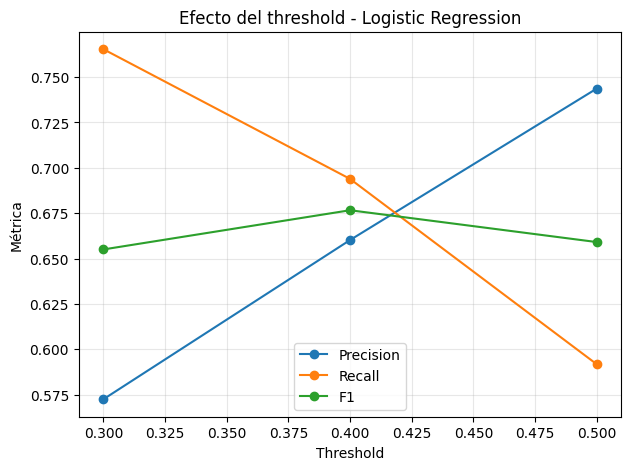

In [47]:
#Visualizar el trade-off
plt.figure(figsize=(7, 5))
plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)
plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)
plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)
plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.title("Efecto del threshold - Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 11.1 Interpretación del ajuste de threshold

Con el threshold predeterminado de 0.50, la Regresión Logística obtiene un recall de 0.5918 y genera 40 falsos negativos.

Al reducir el threshold a 0.40:

- el recall aumenta de 0.5918 a 0.6939;
- los falsos negativos disminuyen de 40 a 30;
- la precision disminuye de 0.7436 a 0.6602;
- los falsos positivos aumentan de 20 a 35;
- el F1 aumenta ligeramente de 0.6591 a 0.6766.

Con un threshold de 0.30, el recall aumenta hasta 0.7653 y los falsos negativos disminuyen a 23. Sin embargo, la precision baja a 0.5725, los falsos positivos aumentan a 56 y el F1 disminuye a 0.6550.

Entre los thresholds evaluados para la Regresión Logística, 0.40 presenta el mejor compromiso: mejora de forma considerable la detección de churn respecto de 0.50 sin alcanzar el aumento de falsas alertas observado con 0.30.

### 11.2 Cálculo reproducible de las métricas

La tabla de decisión no utiliza valores escritos manualmente. Todas las métricas se calculan directamente a partir de las predicciones obtenidas sobre el conjunto de validación.

Las métricas se definen como:

\[
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
\]

\[
Precision = \frac{TP}{TP + FP}
\]

\[
Recall = \frac{TP}{TP + FN}
\]

\[
F1 = 2\left(\frac{Precision \cdot Recall}{Precision + Recall}\right)
\]

Donde:

- \(TP\): jugadores con churn detectados correctamente;
- \(TN\): jugadores sin churn clasificados correctamente;
- \(FP\): jugadores sin churn clasificados erróneamente como churn;
- \(FN\): jugadores con churn que el modelo no detectó.

ROC-AUC se calcula a partir de las probabilidades generadas por cada modelo y evalúa su capacidad de separar ambas clases considerando todos los posibles umbrales.

En el caso de la Regresión Logística con threshold 0.40, las clases se vuelven a generar desde las probabilidades:

\[
\hat{y}=
\begin{cases}
1, & \text{si } P(churn) \geq 0.40 \\
0, & \text{si } P(churn) < 0.40
\end{cases}
\]

In [48]:
# Tabla de decisión calculada automáticamente

def calcular_metricas_modelo(
    nombre,
    y_real,
    y_pred,
    y_prob
):
    tn, fp, fn, tp = confusion_matrix(
        y_real,
        y_pred
    ).ravel()

    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(
            y_real,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_real,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_real,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(y_real, y_prob),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


# Predicción de la regresión logística con threshold 0.40
y_val_pred_log_040 = (
    y_val_prob_log >= 0.40
).astype(int)


# Construcción automática de la tabla
decision_modelos = pd.DataFrame([
    calcular_metricas_modelo(
        "DummyClassifier",
        y_val,
        y_val_pred_dummy,
        y_val_prob_dummy
    ),
    calcular_metricas_modelo(
        "Logistic Regression (0.50)",
        y_val,
        y_val_pred_log,
        y_val_prob_log
    ),
    calcular_metricas_modelo(
        "Logistic Regression (0.40)",
        y_val,
        y_val_pred_log_040,
        y_val_prob_log
    ),
    calcular_metricas_modelo(
        "Decision Tree",
        y_val,
        y_val_pred_arbol,
        y_val_prob_arbol
    )
])

display(
    decision_modelos
    .set_index("Modelo")
    .round(4)
)

,Accuracy,Precision,Recall,F1,ROC_AUC,TN,FP,FN,TP
Modelo,,,,,,,,,
DummyClassifier,0.6410,0.0000,0.0000,0.0000,0.5000,175,0,98,0
Logistic Regression (0.50),0.7802,0.7436,0.5918,0.6591,0.8031,155,20,40,58
Logistic Regression (0.40),0.7619,0.6602,0.6939,0.6766,0.8031,140,35,30,68
Decision Tree,0.8205,0.8182,0.6429,0.7200,0.7764,161,14,35,63


## 12. Selección preliminar del modelo

Los resultados muestran dos alternativas competitivas con comportamientos diferentes.

El Árbol de Decisión presenta el mejor equilibrio general con su configuración actual:

- accuracy: 0.8205;
- precision: 0.8182;
- recall: 0.6429;
- F1: 0.7200;
- 14 falsos positivos;
- 35 falsos negativos.

La Regresión Logística presenta un ROC-AUC superior, con 0.8031 frente a 0.7764, lo que indica una mejor capacidad global para ordenar a los jugadores según su probabilidad de churn.

Al utilizar un threshold de 0.40, la Regresión Logística alcanza un recall de 0.6939 y reduce los falsos negativos a 30. Sin embargo, produce 35 falsos positivos y su F1 disminuye a 0.6766.

En comparación con el Árbol de Decisión, la Regresión Logística con threshold 0.40 detecta cinco casos adicionales de churn, pero genera 21 falsas alertas adicionales.

Debido a que no se dispone todavía de una estimación económica del costo de cada tipo de error, se selecciona preliminarmente el **Árbol de Decisión** como modelo con mejor desempeño equilibrado, al presentar el mayor F1, accuracy y precision, además de una cantidad menor de errores totales.

La Regresión Logística con threshold 0.40 permanece como una alternativa operativa si posteriormente se demuestra que el costo de no detectar un jugador con churn es considerablemente mayor que el costo de generar una intervención innecesaria.

La selección se realiza exclusivamente con el conjunto de validación. El conjunto de prueba permanece reservado para una evaluación posterior.

### 12.1 Tabla de decisión

| Criterio | Mejor alternativa | Justificación |
|---|---|---|
| Accuracy | Árbol de Decisión | Obtiene 0.8205, el valor más alto entre los modelos |
| Precision | Árbol de Decisión | Alcanza 0.8182 y limita las falsas alertas |
| Recall | Regresión Logística, threshold 0.40 | Detecta 69.39% de los casos de churn |
| F1 | Árbol de Decisión | Obtiene 0.7200, el mejor equilibrio entre precision y recall |
| ROC-AUC | Regresión Logística | Obtiene 0.8031 y presenta mejor separación global |
| Falsos positivos | Árbol de Decisión | Genera 14 frente a 35 de la Regresión Logística con threshold 0.40 |
| Falsos negativos | Regresión Logística, threshold 0.40 | Genera 30 frente a 35 del Árbol de Decisión |
| Desempeño equilibrado | Árbol de Decisión | Presenta mayor F1, accuracy y precision |
| Prioridad exclusiva en recall | Regresión Logística, threshold 0.40 | Es alternativa si el costo del falso negativo resulta mucho mayor |
| Selección preliminar | Árbol de Decisión | Mejor balance sin asumir costos empresariales que todavía no se han cuantificado |

## 13. Plan de mejora para la siguiente fase

Los resultados obtenidos permiten establecer una línea base funcional, pero existen varias oportunidades para mejorar la robustez, capacidad predictiva e interpretabilidad del sistema.

| Mejora propuesta | Justificación |
|---|---|
| Evaluar modelos de ensamble | Random Forest y Gradient Boosting pueden capturar relaciones no lineales e interacciones que la Regresión Logística no representa directamente |
| Evaluar SVM | Permitirá comparar una familia de modelos con fronteras de decisión diferentes |
| Ajustar hiperparámetros | La configuración actual es deliberadamente inicial; una búsqueda controlada puede mejorar desempeño sin utilizar el conjunto de prueba |
| Implementar validación cruzada | Permitirá determinar si los resultados son estables y no dependen excesivamente de una sola partición entrenamiento-validación |
| Seleccionar características | El dataset contiene 159 predictores y varias variables relacionadas, por lo que una reducción puede disminuir redundancia y complejidad |
| Crear características derivadas | Relaciones entre actividad reciente, actividad histórica y permanencia podrían producir indicadores más informativos |
| Incorporar interpretabilidad | Coeficientes, importancia de variables, permutation importance o SHAP permitirán explicar qué características influyen en las predicciones |
| Analizar desempeño por subgrupos | Será necesario revisar si el modelo mantiene un comportamiento consistente entre grupos disponibles en los datos |
| Serializar el pipeline | Permitirá conservar conjuntamente el preprocesamiento y el modelo entrenado para reutilizarlo sin reconstruir manualmente el flujo |
| Construir un mecanismo de inferencia | Un script o interfaz mínima permitirá ingresar datos de un jugador y obtener probabilidad de churn y clasificación |
| Diseñar monitoreo | Se deberán definir indicadores de calidad de datos, drift y desempeño para determinar cuándo revisar o reentrenar el modelo |

Estas mejoras buscan atender las principales limitaciones de la primera fase: comparación limitada de algoritmos, ausencia de validación cruzada, elevada dimensionalidad, falta de interpretabilidad avanzada y ausencia de un mecanismo operativo de inferencia.

## 14. Conclusiones de la Fase 1

La primera fase permitió transformar el problema de retención de jugadores en una tarea reproducible de clasificación binaria y distinguir dos comportamientos de abandono diferentes.

El análisis exploratorio mostró que 273 jugadores registraron una sola sesión y que 267 de ellos presentan churn, lo que representa una tasa de abandono inmediato de 97.80%. En cambio, entre los 1,823 jugadores con dos o más sesiones, la tasa de churn disminuye a 35.93%.

Debido a esta diferencia, el modelo se enfocó específicamente en predecir **churn posterior entre jugadores que regresaron al juego al menos una vez**. Los jugadores de una sola sesión permanecieron en el análisis exploratorio, pero fueron excluidos del entrenamiento para evitar que `session_count` dominara artificialmente el aprendizaje.

El análisis de dispersión mostró que `session_count` tiene una media de 2.98 sesiones y una desviación estándar de 1.64. Su valor máximo, 15 sesiones, se encuentra aproximadamente 7.34 desviaciones estándar por encima de la media. Aunque constituye un valor estadísticamente extremo, se conservó porque representa un comportamiento posible y no un error de registro.

Antes del entrenamiento se excluyeron:

- `player_id`, por ser un identificador único sin capacidad de generalización;
- `player_type`, por riesgo de leakage conceptual asociado con la generación sintética de los datos;
- `cohort_id`, por posible dependencia de artefactos temporales;
- 24 variables constantes, debido a que presentan varianza cero;
- `player_churn`, que se separó como variable objetivo.

La población predictiva quedó formada por 1,823 jugadores y 159 características. Los datos se dividieron de forma estratificada en 1,276 observaciones de entrenamiento, 273 de validación y 274 de prueba.

El DummyClassifier alcanzó 64.10% de accuracy, pero fue incapaz de detectar casos de churn, confirmando que accuracy no resulta suficiente para evaluar el problema.

Entre los modelos iniciales, el Árbol de Decisión presentó el mejor desempeño equilibrado en validación:

- accuracy: 0.8205;
- precision: 0.8182;
- recall: 0.6429;
- F1: 0.7200;
- ROC-AUC: 0.7764.

La Regresión Logística obtuvo un ROC-AUC superior de 0.8031. Al reducir su threshold a 0.40, el recall aumentó a 0.6939 y los falsos negativos disminuyeron a 30, aunque los falsos positivos aumentaron a 35 y el F1 quedó en 0.6766.

Por lo tanto, se seleccionó preliminarmente el **Árbol de Decisión con threshold predeterminado de 0.50**, ya que presentó el mejor balance sin asumir costos empresariales todavía no cuantificados. La Regresión Logística con threshold 0.40 permanece como alternativa si posteriormente se determina que el costo de un falso negativo es considerablemente mayor.

### Limitaciones

Los datos son sintéticos, por lo que los resultados no pueden generalizarse directamente a un videojuego real.

El modelo está dirigido exclusivamente a jugadores con dos o más sesiones. Por ello, no debe utilizarse para predecir el abandono inmediato después de la primera experiencia.

También se asume que las variables históricas de actividad estarían disponibles antes del momento de inferencia. En un sistema real sería necesario definir con precisión la ventana de observación para evitar fuga de información temporal.

La comparación se realizó con una sola partición de validación y sin optimización extensa de hiperparámetros. Además, todavía no se dispone de una matriz de costos que permita cuantificar económicamente los falsos positivos y falsos negativos.

### Trabajo posterior

En la siguiente fase se podrán evaluar modelos adicionales, aplicar validación cruzada, optimizar hiperparámetros, seleccionar características, analizar interpretabilidad y realizar la evaluación final sobre el conjunto de prueba reservado.

## 15. Reproducibilidad y trazabilidad

La configuración principal del experimento es:

- **Dataset:** `player-churn.csv`
- **Observaciones originales:** 2,096
- **Población utilizada para modelado:** 1,823 jugadores
- **Jugadores de una sola sesión excluidos del modelado:** 273
- **Variables originales:** 187
- **Predictores finales:** 159
- **Random seed:** 42
- **División:** 70% entrenamiento, 15% validación y 15% prueba
- **Entrenamiento:** 1,276 jugadores
- **Validación:** 273 jugadores
- **Prueba:** 274 jugadores
- **Estratificación:** aplicada sobre `player_churn`
- **Clase positiva:** churn = 1
- **Modelo preliminar seleccionado:** Árbol de Decisión
- **Threshold preliminar:** 0.50
- **Entorno:** Google Colab

El preprocesamiento y los modelos se ajustaron utilizando únicamente el conjunto de entrenamiento. El conjunto de validación se utilizó para comparar modelos y thresholds. El conjunto de prueba permaneció reservado y no participó en la selección preliminar.

### Tabla de trazabilidad

| Elemento | Detalle |
|---|---|
| Dataset | `player-churn.csv` |
| Fuente | AWS Player Churn sample dataset |
| Observaciones originales | 2,096 |
| Población de modelado | 1,823 jugadores con dos o más sesiones |
| Variable objetivo | `player_churn` |
| Clase positiva | Churn = 1 |
| Predictores finales | 159 |
| Semilla | 42 |
| División | 70% entrenamiento / 15% validación / 15% prueba |
| Pipeline | Imputación, escalamiento y One-Hot Encoding mediante `ColumnTransformer` |
| Baseline | DummyClassifier con estrategia `most_frequent` |
| Modelo 1 | LogisticRegression, `max_iter=2000`, `random_state=42` |
| Modelo 2 | DecisionTreeClassifier, `max_depth=5`, `random_state=42` |
| Métricas | Accuracy, precision, recall, F1 y ROC-AUC |
| Mejor modelo equilibrado | Árbol de Decisión |
| Threshold seleccionado | 0.50 |
| Accuracy de validación | 0.8205 |
| Precision de validación | 0.8182 |
| Recall de validación | 0.6429 |
| F1 de validación | 0.7200 |
| ROC-AUC de validación | 0.7764 |
| Alternativa de mayor recall | Regresión Logística con threshold 0.40 |
| Entorno | Google Colab |
| Archivo principal | `Player_Churn_Risk_Prediction.ipynb` |
| Fecha de ejecución | Registrada automáticamente en la celda de entorno |

In [49]:
#Registro del entorno para reproducibilidad
import sys
import platform
import pandas as pd
import numpy as np
import sklearn
from datetime import datetime
print("Fecha de ejecución:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Python:", sys.version.split()[0])
print("Sistema:", platform.platform())
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Random seed:", 42)
print("Dataset:", archivo)
print("Dimensiones originales:", df.shape)

Fecha de ejecución: 2026-09-02 05:46:00
Python: 3.13.15
Sistema: Linux-6.6.122+-x86_64-with-glibc2.35
Pandas: 2.2.3
NumPy: 2.1.3
Scikit-learn: 1.6.1
Random seed: 42
Dataset: player-churn (3).csv
Dimensiones originales: (2096, 187)
